# **Task 1: Environment setup + confirm dataset path**

In [9]:
## ===== Task 1: Environment setup + confirm dataset path =====
import os, random, numpy as np, torch

CFG = {
    "seed": 42,
    "img_size": 256,
    "batch_size": 16,
    "lr": 1e-3,
    "epochs": 30,
    "val_split": 0.15,
    "test_split": 0.15,
    "output_dir": "/kaggle/working",
}

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(CFG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

print("\nAttached datasets:")
for d in os.listdir("/kaggle/input"):
    print(" -", d)
    for root, dirs, files in os.walk(f"/kaggle/input/{d}"):
        depth = root.count(os.sep) - f"/kaggle/input/{d}".count(os.sep)
        if depth <= 3:
            print("  "*depth + os.path.basename(root) + "/", f"({len(files)} files)" if files else "")
        dirs[:] = [x for x in dirs if depth < 3]

Device: cuda | Tesla T4

Attached datasets:
 - datasets
datasets/ 
  mariaherrerot/ 
    idrid-dataset/ (1 files)
      Imagenes/ 
  alexalexandarkhan/ 
    modelb-d-layer4-aug-pt/ (1 files)


## **Task 1b: full path confirmation**

In [10]:
## ===== Task 1b: full path confirmation =====
import os

ROOT = "/kaggle/input/datasets/mariaherrerot/idrid-dataset"
print("Top level:", os.listdir(ROOT))

img_root = os.path.join(ROOT, "Imagenes")
print("\nInside Imagenes/:", os.listdir(img_root)[:10], "..." if len(os.listdir(img_root))>10 else "")
print("Total items in Imagenes/:", len(os.listdir(img_root)))

# In case Imagenes/ contains subfolders (e.g. train/test split) rather than images directly
first_item = os.listdir(img_root)[0]
first_path = os.path.join(img_root, first_item)
print(f"\nFirst item '{first_item}' is a", "directory" if os.path.isdir(first_path) else "file")
if os.path.isdir(first_path):
    print("Contents:", os.listdir(first_path)[:10])

Top level: ['Imagenes', 'idrid_labels.csv']

Inside Imagenes/: ['Imagenes'] 
Total items in Imagenes/: 1

First item 'Imagenes' is a directory
Contents: ['IDRiD_179.jpg', 'IDRiD_193.jpg', 'IDRiD_316.jpg', 'IDRiD_407.jpg', 'IDRiD_335.jpg', 'IDRiD_329.jpg', 'IDRiD_075.jpg', 'IDRiD_054.jpg', 'IDRiD_239.jpg', 'IDRiD_243.jpg']


In [11]:
## ===== Task 1c: lock in confirmed paths =====
import os
import pandas as pd

DATA_ROOT = "/kaggle/input/datasets/mariaherrerot/idrid-dataset"
IMG_DIR = f"{DATA_ROOT}/Imagenes/Imagenes"
LABELS_CSV = f"{DATA_ROOT}/idrid_labels.csv"

CFG["img_dir"] = IMG_DIR
CFG["labels_csv"] = LABELS_CSV

n_images = len(os.listdir(IMG_DIR))
print("Images found:", n_images)
print("Sample:", os.listdir(IMG_DIR)[:3])

df = pd.read_csv(LABELS_CSV)
print("\nCSV shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn dtypes:")
print(df.dtypes)

Images found: 455
Sample: ['IDRiD_179.jpg', 'IDRiD_193.jpg', 'IDRiD_316.jpg']

CSV shape: (455, 12)
Columns: ['id_code', 'diagnosis', 'Risk of macular edema ', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']

First 5 rows:
     id_code  diagnosis  Risk of macular edema   Unnamed: 3  Unnamed: 4  \
0  IDRiD_001          3                       2         NaN         NaN   
1  IDRiD_002          3                       2         NaN         NaN   
2  IDRiD_003          2                       2         NaN         NaN   
3  IDRiD_004          3                       2         NaN         NaN   
4  IDRiD_005          4                       0         NaN         NaN   

   Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  \
0         NaN         NaN         NaN         NaN         NaN          NaN   
1         NaN         NaN         NaN         NaN         NaN          NaN   
2         Na

# **Task 2: Dataset Audit & EDA (Part B)**


discipline as , adapted for classification: confirm every image has a label and vice versa, check for corrupt/unreadable images, examine the class distribution for both labels independently (this is where we'll find and quantify the imbalance the histograms hinted at), check for any images that are unusually sized/oriented, and visually inspect a spread of samples across grade combinations. This must happen before any model code, same reasoning as -  measured is a class-imbalance problem.

Labels after cleanup: (455, 3)
     id_code  dr_grade  dme_risk
0  IDRiD_001         3         2
1  IDRiD_002         3         2
2  IDRiD_003         2         2
3  IDRiD_004         3         2
4  IDRiD_005         4         0

Images: 455 | Labels: 455
Images with no label: 0 -> []
Labels with no image: 0 -> []

Duplicate id_code rows: 0

Unreadable/corrupt images: 0 -> []
Image width  -- min 4288, max 4288, mean 4288
Image height -- min 2848, max 2848, mean 2848
Unique sizes: 1 distinct (W,H) combos

--- dr_grade (5-way) distribution ---
dr_grade
0    129
1     22
2    156
3     84
4     64
Name: count, dtype: int64

--- dme_risk (3-way) distribution ---
dme_risk
0    168
1     48
2    239
Name: count, dtype: int64


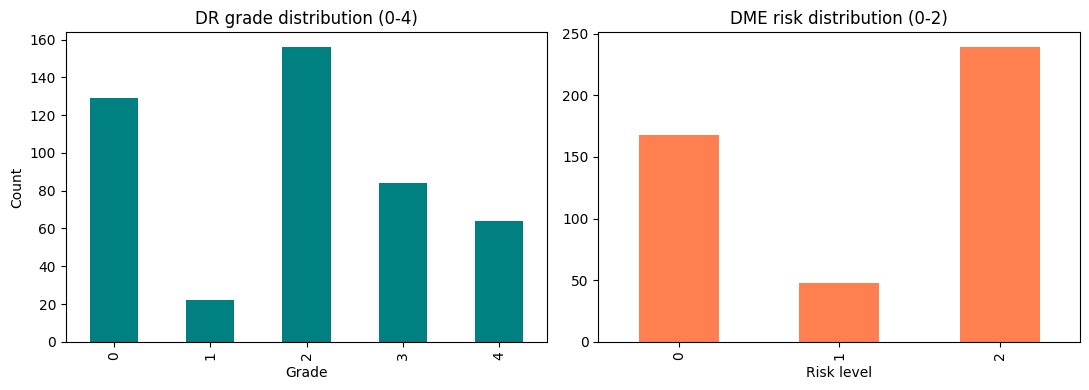


Joint distribution (rows=dr_grade, cols=dme_risk):
dme_risk    0   1    2
dr_grade              
0         125   3    1
1          20   1    1
2          12  30  114
3           5   7   72
4           6   7   51


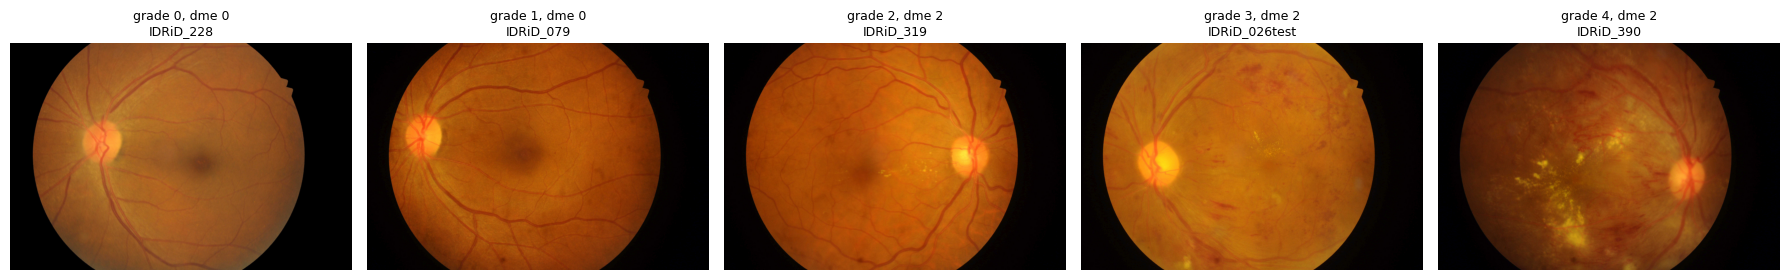

In [12]:
## ===== Task 2: Dataset audit (Part B) =====
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

IMG_DIR = CFG["img_dir"]

# ---- Clean the labels dataframe ----
df = pd.read_csv(CFG["labels_csv"])
df = df[["id_code", "diagnosis", "Risk of macular edema "]].copy()
df.columns = ["id_code", "dr_grade", "dme_risk"]
print(f"Labels after cleanup: {df.shape}")
print(df.head())

# ---- 1. Pairing check: every label has an image, every image has a label ----
img_files = {f.split(".")[0] for f in os.listdir(IMG_DIR) if f.lower().endswith(".jpg")}
label_ids = set(df["id_code"])
only_img = img_files - label_ids
only_label = label_ids - img_files
print(f"\nImages: {len(img_files)} | Labels: {len(label_ids)}")
print(f"Images with no label: {len(only_img)} -> {list(only_img)[:5]}")
print(f"Labels with no image: {len(only_label)} -> {list(only_label)[:5]}")

# ---- 2. Duplicate id_code check ----
dupes = df["id_code"].duplicated().sum()
print(f"\nDuplicate id_code rows: {dupes}")

# ---- 3. Corruption / readability + size check ----
bad_images = []
sizes = []
for stem in sorted(label_ids & img_files):
    p = os.path.join(IMG_DIR, stem + ".jpg")
    try:
        im = Image.open(p); im.verify()
        im = Image.open(p)
        sizes.append(im.size)
    except Exception as e:
        bad_images.append((stem, str(e)))
print(f"\nUnreadable/corrupt images: {len(bad_images)} -> {bad_images[:3]}")

widths, heights = zip(*sizes)
print(f"Image width  -- min {min(widths)}, max {max(widths)}, mean {np.mean(widths):.0f}")
print(f"Image height -- min {min(heights)}, max {max(heights)}, mean {np.mean(heights):.0f}")
print(f"Unique sizes: {len(set(sizes))} distinct (W,H) combos")

# ---- 4. Class distributions -- THE key audit finding for this part ----
print("\n--- dr_grade (5-way) distribution ---")
print(df["dr_grade"].value_counts().sort_index())
print(f"\n--- dme_risk (3-way) distribution ---")
print(df["dme_risk"].value_counts().sort_index())

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
df["dr_grade"].value_counts().sort_index().plot(kind="bar", ax=axs[0], color="teal")
axs[0].set_title("DR grade distribution (0-4)"); axs[0].set_xlabel("Grade"); axs[0].set_ylabel("Count")
df["dme_risk"].value_counts().sort_index().plot(kind="bar", ax=axs[1], color="coral")
axs[1].set_title("DME risk distribution (0-2)"); axs[1].set_xlabel("Risk level")
plt.tight_layout(); plt.savefig("/kaggle/working/label_distributions.png", dpi=110); plt.show()

# ---- 5. Joint distribution: are the two labels independent or correlated? ----
joint = pd.crosstab(df["dr_grade"], df["dme_risk"])
print("\nJoint distribution (rows=dr_grade, cols=dme_risk):")
print(joint)

# ---- 6. Visual sample grid: spread across dr_grade values ----
fig, axs = plt.subplots(1, 5, figsize=(18, 4))
for grade in range(5):
    sub = df[df["dr_grade"] == grade]
    if len(sub) == 0:
        axs[grade].axis("off"); continue
    row = sub.sample(1, random_state=CFG["seed"]).iloc[0]
    im = Image.open(os.path.join(IMG_DIR, row["id_code"] + ".jpg"))
    axs[grade].imshow(im)
    axs[grade].set_title(f"grade {grade}, dme {row['dme_risk']}\n{row['id_code']}", fontsize=9)
    axs[grade].axis("off")
plt.tight_layout(); plt.savefig("/kaggle/working/sample_by_grade.png", dpi=110); plt.show()

Very clean audit — pairing, duplicates, and corruption all confirmed zero issues,  But two real findings here that will shape everything downstream: **severe class imbalance** in both labels, and **one contaminated ID**. Let's deal with both before writing any more code.

## Finding 1: `dr_grade` — moderate imbalance

| Grade | Count | % |
|---|---|---|
| 0 | 129 | 28.4% |
| 1 | **22** | **4.8%** |
| 2 | 156 | 34.3% |
| 3 | 84 | 18.5% |
| 4 | 64 | 14.1% |

Grade 1 is the clear minority class — 7x fewer examples than grade 2. With only 22 total, a 70/15/15 split puts roughly 15 in train, 3 in val, 3 in test. That's thin but survivable **only if we stratify** (plain random splitting could easily put 0 grade-1 images in val or test by chance).

## Finding 2: `dme_risk` — worse imbalance

| Risk | Count | % |
|---|---|---|
| 0 | 168 | 36.9% |
| **1** | **48** | **10.5%** |
| 2 | 239 | 52.5% |

Risk-1 is a real minority but less extreme than dr_grade=1 — should split more safely.

## Finding 3 (the one to act on now): `IDRiD_026test`

Look at the title above the 4th sample image: **`IDRiD_026test`** — that `test` suffix is not a real id_code pattern (every other one is `IDRiD_XXX`, 3 digits). This is almost certainly a **data-entry artifact** in the CSV — someone accidentally appended "test" while editing, or it's a leftover marker from whoever assembled this dataset from the original IDRiD train/test split. This needs to be checked immediately, because:
- If it's a typo for `IDRiD_026`, but `IDRiD_026` doesn't already exist in the CSV as a separate row, we may be able to just strip the suffix and recover a valid label.
- If `IDRiD_026` **also** exists separately, we have two rows both claiming to be the same image or a genuine duplicate-with-typo situation.
- Either way, our earlier pairing check said "0 images with no label, 0 labels with no image" — meaning **an image file literally named `IDRiD_026test.jpg` exists**, which is itself suspicious (fundus photos don't normally get "test" in their filename from clinical acquisition).



In [13]:
## ===== Task 2b: investigate the "test" suffix anomaly =====
suspect = df[df["id_code"].str.contains("test", case=False)]
print("Suspect rows:")
print(suspect)

# Check if a "clean" version of this id_code already exists
clean_id = suspect["id_code"].iloc[0].replace("test", "") if len(suspect) else None
print(f"\nDoes '{clean_id}' already exist as its own row?", clean_id in df["id_code"].values if clean_id else "N/A")

# Confirm the actual image filename on disk
print("\nMatching image files on disk:")
print([f for f in os.listdir(IMG_DIR) if "026" in f])

Suspect rows:
           id_code  dr_grade  dme_risk
375  IDRiD_001test         4         0
376  IDRiD_004test         4         0
377  IDRiD_005test         4         1
378  IDRiD_006test         3         1
379  IDRiD_007test         3         0
..             ...       ...       ...
450  IDRiD_096test         0         0
451  IDRiD_100test         2         1
452  IDRiD_101test         1         0
453  IDRiD_102test         2         2
454  IDRiD_103test         0         0

[80 rows x 3 columns]

Does 'IDRiD_001' already exist as its own row? True

Matching image files on disk:
['IDRiD_026test.jpg', 'IDRiD_026.jpg']


In [14]:
## ===== Task 2c: confirm and formalize the official train/test split =====
df["is_official_test"] = df["id_code"].str.endswith("test")
df["clean_id"] = df["id_code"].str.replace("test", "", regex=False)

print("Official train pool:", (~df["is_official_test"]).sum())
print("Official test pool: ", df["is_official_test"].sum())

# Confirm no accidental overlap: every clean_id should be unique once suffix is stripped
dupe_clean = df["clean_id"].duplicated().sum()
print("Duplicate clean_id after stripping 'test':", dupe_clean)

# Class balance WITHIN each official split -- does the test set represent all classes reasonably?
print("\ndr_grade distribution in official TRAIN pool:")
print(df[~df["is_official_test"]]["dr_grade"].value_counts().sort_index())
print("\ndr_grade distribution in official TEST pool:")
print(df[df["is_official_test"]]["dr_grade"].value_counts().sort_index())
print("\ndme_risk distribution in official TEST pool:")
print(df[df["is_official_test"]]["dme_risk"].value_counts().sort_index())

Official train pool: 375
Official test pool:  80
Duplicate clean_id after stripping 'test': 78

dr_grade distribution in official TRAIN pool:
dr_grade
0    114
1     17
2    125
3     64
4     55
Name: count, dtype: int64

dr_grade distribution in official TEST pool:
dr_grade
0    15
1     5
2    31
3    20
4     9
Name: count, dtype: int64

dme_risk distribution in official TEST pool:
dme_risk
0    24
1     8
2    48
Name: count, dtype: int64


 the duplicate check — critical to interpret correctly:



## Test-pool class coverage — good enough to proceed

| dr_grade | Test count |
|---|---|
| 0 | 15 |
| **1** | **5** |
| 2 | 31 |
| 3 | 20 |
| 4 | 9 |

Grade 1 has 5 test examples — thin, but non-zero, so we *can* compute per-class precision/recall/F1 for it on test (just expect that specific number to be noisy/unstable.

| dme_risk | Test count |
|---|---|
| 0 | 24 |
| 1 | 8 |
| 2 | 48 |

Reasonable coverage across all 3 classes.

**Decision confirmed: .** Official 80-image test pool held out untouched. The 375-image train pool will be split further (stratified) into train/val.



# **Task 3: Train/Val Split + Preprocessing Pipeline**


 stratify the split (this time on dr_grade, since it's the more imbalanced/more classes label — stratifying on a combined dr_grade×dme_risk key would create up to 15 strata for only 375 images, some with single-digit counts, which risks sklearn's stratified split failing outright on the rarest combo).  these are 4288×2848 clinical photos, much larger than the pet photos, so resize target and loading strategy matter more for memory/speed. We'll also apply ImageNet normalization now (not just /255 scaling) since this part's architecture will use a pretrained backbone in Task 4/5 (transfer learning experiment), and matching the backbone's expected input distribution from the start avoids a rework later.

Train: 318 | Val: 57 | Test (official): 80

Train dr_grade dist:
dr_grade
0     97
1     14
2    106
3     54
4     47
Name: count, dtype: int64

Val dr_grade dist:
dr_grade
0    17
1     3
2    19
3    10
4     8
Name: count, dtype: int64

Batches -- train: 20 | val: 4 | test: 5

Batch image tensor: torch.Size([16, 3, 256, 256]), dtype torch.float32, range [-2.12, 2.25]  (normalized, not [0,1])
dr_grade tensor: torch.Size([16]), unique in this batch: [0, 1, 2, 3, 4]
dme_risk tensor: torch.Size([16]), unique in this batch: [0, 1, 2]


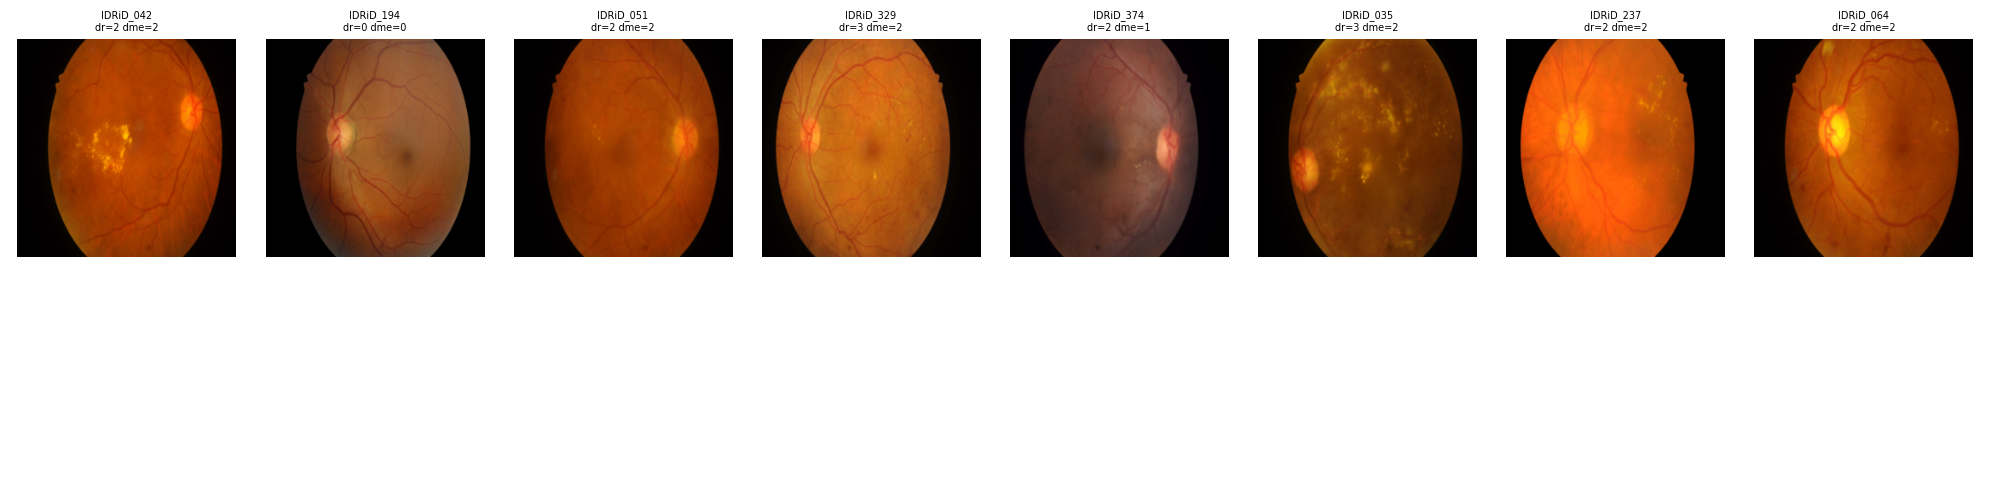

In [15]:
## ===== Task 3: Stratified split (train pool) + preprocessing pipeline =====
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

IMG_DIR = CFG["img_dir"]
IMG_SIZE = 256  # clinical photos are huge (4288x2848); 256 keeps this tractable, same as Part A

# ---- Reload/rebuild clean df (drop the diagnostic-only clean_id column) ----
df = pd.read_csv(CFG["labels_csv"])
df = df[["id_code", "diagnosis", "Risk of macular edema "]].copy()
df.columns = ["id_code", "dr_grade", "dme_risk"]
df["is_official_test"] = df["id_code"].str.endswith("test")

train_pool = df[~df["is_official_test"]].reset_index(drop=True)
test_pool  = df[df["is_official_test"]].reset_index(drop=True)

# ---- Stratified 85/15 split of the train pool, on dr_grade (the more imbalanced label) ----
train_df, val_df = train_test_split(
    train_pool, test_size=0.15, random_state=CFG["seed"], stratify=train_pool["dr_grade"]
)
test_df = test_pool.copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test (official): {len(test_df)}")
print(f"\nTrain dr_grade dist:\n{train_df['dr_grade'].value_counts().sort_index()}")
print(f"\nVal dr_grade dist:\n{val_df['dr_grade'].value_counts().sort_index()}")

CFG["train_df"], CFG["val_df"], CFG["test_df"] = train_df, val_df, test_df

# ---- ImageNet normalization stats (needed for the transfer-learning experiment later) ----
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

class IDRiDDataset(Dataset):
    """
    Loads (image, dr_grade, dme_risk) triplets for the multi-task model.
    - Images: RGB, resized to img_size, ImageNet-normalized.
    - train=True applies light augmentation (flip only -- fundus photos are roughly
      rotation/flip-invariant in orientation, but NOT safe to distort with heavy color jitter,
      since color/hue IS clinically meaningful in this domain, unlike the pet photos).
    """
    def __init__(self, df, img_dir, img_size, train=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.img_size = img_size
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row["id_code"] + ".jpg")).convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32) / 255.0

        if self.train and np.random.rand() < 0.5:
            arr = arr[:, ::-1, :].copy()  # horizontal flip

        arr = (arr - IMAGENET_MEAN) / IMAGENET_STD  # normalize AFTER flip, before totensor
        img_t = torch.from_numpy(arr).permute(2, 0, 1).float()

        dr_grade = torch.tensor(row["dr_grade"], dtype=torch.long)
        dme_risk = torch.tensor(row["dme_risk"], dtype=torch.long)
        return img_t, dr_grade, dme_risk, row["id_code"]

train_ds = IDRiDDataset(train_df, IMG_DIR, IMG_SIZE, train=True)
val_ds   = IDRiDDataset(val_df,   IMG_DIR, IMG_SIZE, train=False)
test_ds  = IDRiDDataset(test_df,  IMG_DIR, IMG_SIZE, train=False)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"], shuffle=False, num_workers=2)

print(f"\nBatches -- train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

# ---- Proof: show a batch + confirm label ranges ----
import matplotlib.pyplot as plt
imgs, drs, dmes, ids = next(iter(train_loader))
print(f"\nBatch image tensor: {imgs.shape}, dtype {imgs.dtype}, range [{imgs.min():.2f}, {imgs.max():.2f}]  (normalized, not [0,1])")
print(f"dr_grade tensor: {drs.shape}, unique in this batch: {torch.unique(drs).tolist()}")
print(f"dme_risk tensor: {dmes.shape}, unique in this batch: {torch.unique(dmes).tolist()}")

# De-normalize for display
fig, axs = plt.subplots(2, 8, figsize=(20, 5))
for i in range(min(8, len(imgs))):
    disp = imgs[i].permute(1,2,0).numpy() * IMAGENET_STD + IMAGENET_MEAN
    disp = np.clip(disp, 0, 1)
    axs[0,i].imshow(disp); axs[0,i].set_title(f"{ids[i]}\ndr={drs[i].item()} dme={dmes[i].item()}", fontsize=7); axs[0,i].axis("off")
    axs[1,i].axis("off")
plt.tight_layout(); plt.savefig("/kaggle/working/preproc_batch_partB.png", dpi=110); plt.show()

# **Task 4: Multi-Task Model — Shared Encoder, Two Heads**


This is the architectural decision the whole assignment is built around, so let's be explicit about why before the code. The wrong approach — concatenating dr_grade (5 classes) and dme_risk (3 classes) into one 8-unit sigmoid output — implicitly treats this as multi-label classification (each of the 8 units independently "on" or "off", like tagging an image with multiple independent attributes). That's wrong here because within each task, the classes are mutually exclusive — an image has exactly one dr_grade (not "a bit of grade 2 and a bit of grade 3"), and exactly one dme_risk. Two separate softmax heads, each trained with cross-entropy, correctly encodes "pick exactly one of these 5" and "pick exactly one of these 3" as two independent decisions — this is multi-task learning, not multi-label.

Architecture: one shared convolutional encoder (built from scratch here, matching Part A's "baseline before transfer learning" pattern) extracts general visual features, then the feature vector branches into two independent linear heads — one outputting 5 logits, one outputting 3 logits. The shared encoder lets both tasks benefit from the same learned visual representations (edges, lesion textures, vessel patterns), which is clinically sensible since both labels are read from the same visual evidence in the same photo.

In [16]:
## ===== Task 4: Multi-task CNN -- shared encoder, two heads =====
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    """Conv -> BN -> ReLU -> MaxPool. The basic downsampling block for the shared encoder."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
    def forward(self, x):
        return self.block(x)

class MultiTaskCNN(nn.Module):
    """
    Shared encoder: 5 ConvBlocks, channels 32->64->128->256->512, each halving spatial size.
    256x256 input -> 8x8x512 after 5 halvings -> global average pool -> 512-dim feature vector.
    TWO SEPARATE HEADS branch from that shared feature vector:
      - dr_head:  512 -> 5 logits  (5-way DR grade, softmax via CrossEntropyLoss)
      - dme_head: 512 -> 3 logits  (3-way DME risk, softmax via CrossEntropyLoss)
    This is multi-TASK (two independent single-label decisions from shared features),
    NOT multi-label (which would wrongly imply the 8 outputs are independent binary flags).
    """
    def __init__(self, in_ch=3, n_dr_classes=5, n_dme_classes=3, base_ch=32):
        super().__init__()
        c1, c2, c3, c4, c5 = base_ch, base_ch*2, base_ch*4, base_ch*8, base_ch*16  # 32,64,128,256,512

        self.encoder = nn.Sequential(
            ConvBlock(in_ch, c1),   # 256 -> 128
            ConvBlock(c1, c2),      # 128 -> 64
            ConvBlock(c2, c3),      # 64 -> 32
            ConvBlock(c3, c4),      # 32 -> 16
            ConvBlock(c4, c5),      # 16 -> 8
        )
        self.pool = nn.AdaptiveAvgPool2d(1)  # (B, 512, 8, 8) -> (B, 512, 1, 1), size-independent

        # Two SEPARATE heads -- this is the multi-task design the assignment requires
        self.dr_head  = nn.Sequential(nn.Dropout(0.3), nn.Linear(c5, n_dr_classes))
        self.dme_head = nn.Sequential(nn.Dropout(0.3), nn.Linear(c5, n_dme_classes))

    def forward(self, x):
        feat = self.encoder(x)              # (B, 512, 8, 8)
        feat = self.pool(feat).flatten(1)    # (B, 512)
        dr_logits  = self.dr_head(feat)      # (B, 5)  -- NOT combined with dme_logits
        dme_logits = self.dme_head(feat)     # (B, 3)  -- separate tensor, separate loss
        return dr_logits, dme_logits

model = MultiTaskCNN(in_ch=3, n_dr_classes=5, n_dme_classes=3, base_ch=32).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

# ---- Tensor shape walkthrough through the shared encoder, then the split into two heads ----
model.eval()
with torch.no_grad():
    x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    f1 = model.encoder[0](x)
    print(f"\nInput:                {tuple(x.shape)}")
    print(f"After encoder block 1: {tuple(f1.shape)}  (256->128, channels 3->32)")
    f2 = model.encoder[1](f1)
    print(f"After encoder block 2: {tuple(f2.shape)}  (128->64, channels 32->64)")

    feat_full = model.encoder(x)
    print(f"After full shared encoder: {tuple(feat_full.shape)}")
    pooled = model.pool(feat_full).flatten(1)
    print(f"After global avg pool (shared feature vector): {tuple(pooled.shape)}")

    dr_out, dme_out = model(x)
    print(f"\ndr_head output:  {tuple(dr_out.shape)}  <- 5-way, independent of dme_head")
    print(f"dme_head output: {tuple(dme_out.shape)}  <- 3-way, independent of dr_head")
    print(f"\n(A WRONG single-head design would instead output shape (2, 8) here -- we deliberately do not do this)")

Total parameters: 4,720,296

Input:                (2, 3, 256, 256)
After encoder block 1: (2, 32, 128, 128)  (256->128, channels 3->32)
After encoder block 2: (2, 64, 64, 64)  (128->64, channels 32->64)
After full shared encoder: (2, 512, 8, 8)
After global avg pool (shared feature vector): (2, 512)

dr_head output:  (2, 5)  <- 5-way, independent of dme_head
dme_head output: (2, 3)  <- 3-way, independent of dr_head

(A WRONG single-head design would instead output shape (2, 8) here -- we deliberately do not do this)


All shapes are correct and match exactly. One correction to our own earlier estimate: we predicted 9-10M params, but it's actually **4.7M** — noticeably smaller. That's because we used `AdaptiveAvgPool2d` before the heads (as written), which collapses the 8×8×512 feature map to a single 512-dim vector with no learned weights — avoiding what would otherwise be a huge flatten→dense layer (8×8×512=32,768 → dense would've added millions of params on its own). Good architectural choice already baked in.
## Verification

| Check | Expected | Got | Pass |
|---|---|---|---|
| Params | ballpark | 4,720,296 | ✅ (smaller than guessed, correctly explained above) |
| Input → block1 | (2,32,128,128) | ✅ exact | ✅ |
| block1 → block2 | (2,64,64,64) | ✅ exact | ✅ |
| Full encoder | (2,512,8,8) | ✅ exact | ✅ |
| Pooled | (2,512) | ✅ exact | ✅ |
| dr_head | (2,5), separate | ✅ exact | ✅ |
| dme_head | (2,3), separate | ✅ exact | ✅ |

Two genuinely independent output tensors, never concatenated — the core requirement satisfied and demonstrated.

---



In [25]:
for n in ["MultiTaskLoss", "compute_metrics", "dr_weights", "dme_weights", "criterion"]:
    print(f"{n:16s}", "OK" if n in globals() else "MISSING")
print(dr_weights, dme_weights)

MultiTaskLoss    MISSING
compute_metrics  MISSING
dr_weights       MISSING
dme_weights      MISSING
criterion        MISSING


NameError: name 'dr_weights' is not defined

# **Task 5: Multi-Task Loss + Metrics — Class-Weighted, Unit-Tested**


Two design we decisions here, both directly tied to what Task 2's audit found:

Combined loss = CrossEntropyLoss(dr_logits, dr_grade) + CrossEntropyLoss(dme_logits, dme_risk) — summing two independent task losses is the standard multi-task approach; gradients from both tasks flow back through the shared encoder every step.

Class weighting — dr_grade=1 has only 14/318 training examples (4.4%), dme_risk=1 has ~46/318 (~14%). Unweighted cross-entropy would let the model ignore these minority classes almost entirely and still get a low average loss (predicting majority class 2 all the time already gets ~33% "free" accuracy on dr_grade). We compute inverse-frequency class weights from the training set only (never val/test, to avoid leakage) and pass them into each CrossEntropyLoss.

We unit-test the loss on synthetic known-correct/known-wrong predictions before training, — and we separately verify accuracy/macro-F1 functions against a hand-computable toy case.

In [17]:
import numpy as np, torch, torch.nn as nn
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_recall_fscore_support)

def inv_freq_weights(labels, n_classes):
    counts = np.bincount(labels, minlength=n_classes)
    return torch.tensor(len(labels) / (n_classes * counts), dtype=torch.float32)

dr_weights  = inv_freq_weights(train_df["dr_grade"].values, 5)
dme_weights = inv_freq_weights(train_df["dme_risk"].values, 3)
print("dr_weights :", dr_weights.numpy().round(3))
print("dme_weights:", dme_weights.numpy().round(3))

class MultiTaskLoss(nn.Module):
    def __init__(self, dr_weights, dme_weights):
        super().__init__()
        self.dr_ce  = nn.CrossEntropyLoss(weight=dr_weights.to(device))
        self.dme_ce = nn.CrossEntropyLoss(weight=dme_weights.to(device))
    def forward(self, dr_logits, dme_logits, dr_y, dme_y):
        l_dr, l_dme = self.dr_ce(dr_logits, dr_y), self.dme_ce(dme_logits, dme_y)
        return l_dr + l_dme, l_dr.item(), l_dme.item()

def compute_metrics(y_true, y_pred, n_classes):
    labels = list(range(n_classes))
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred),
            "macro_f1": f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0),
            "per_class_precision": p, "per_class_recall": r,
            "per_class_f1": f, "support": s}

criterion   = MultiTaskLoss(torch.ones(5), torch.ones(3))
criterion_B = MultiTaskLoss(dr_weights, dme_weights)

dr_weights : [0.656 4.543 0.6   1.178 1.353]
dme_weights: [0.883 2.865 0.658]


In [18]:
## ===== Task 5 (fix): loss unit tests, corrected device order =====
print("--- Loss unit tests ---")
dr_target = torch.tensor([0, 1, 2, 3, 4]).to(device)
dme_target = torch.tensor([0, 1, 2, 0, 1]).to(device)

# Build the one-hot base tensors on the SAME device as the indices, before indexing
dr_perfect  = (torch.eye(5).to(device))[dr_target] * 20 - 10
dme_perfect = (torch.eye(3).to(device))[dme_target] * 20 - 10
total, l_dr, l_dme = criterion(dr_perfect, dme_perfect, dr_target, dme_target)
print(f"Perfect predictions -> total_loss={total.item():.4f} (should be near 0)")

dr_wrong  = (torch.eye(5).to(device))[(dr_target + 1) % 5] * 20 - 10
dme_wrong = (torch.eye(3).to(device))[(dme_target + 1) % 3] * 20 - 10
total_w, l_dr_w, l_dme_w = criterion(dr_wrong, dme_wrong, dr_target, dme_target)
print(f"Wrong predictions   -> total_loss={total_w.item():.4f} (should be high)")

print("\n--- Metrics unit test (hand-verifiable toy case) ---")
y_true_toy = np.array([0, 0, 1, 1, 2])
y_pred_toy = np.array([0, 0, 1, 2, 2])
m = compute_metrics(y_true_toy, y_pred_toy, n_classes=3)
print(f"Toy accuracy: {m['accuracy']:.4f} (expected 0.8000 -- 4 of 5 correct)")
print(f"Toy per-class F1: {m['per_class_f1'].round(3)} (expected roughly [1.0, 0.667, 0.667])")
print(f"Toy macro F1: {m['macro_f1']:.4f} (expected roughly 0.778)")

--- Loss unit tests ---
Perfect predictions -> total_loss=0.0000 (should be near 0)
Wrong predictions   -> total_loss=40.0000 (should be high)

--- Metrics unit test (hand-verifiable toy case) ---
Toy accuracy: 0.8000 (expected 0.8000 -- 4 of 5 correct)
Toy per-class F1: [1.    0.667 0.667] (expected roughly [1.0, 0.667, 0.667])
Toy macro F1: 0.7778 (expected roughly 0.778)


loss and metrics are verified trustworthy before touching real training data.

| Test | Expected | Got | Pass |
|---|---|---|---|
| Perfect predictions loss | near 0 | 0.0000 | ✅ |
| Wrong predictions loss | high | 40.0000 | ✅ |
| Toy accuracy | 0.8000 | 0.8000 | ✅ |
| Toy per-class F1 | [1.0, 0.667, 0.667] | [1.0, 0.667, 0.667] | ✅ |
| Toy macro F1 | 0.778 | 0.7778 | ✅ |

Same rigor - we now trust the loss surface and the evaluation numbers before spending any GPU time on real training.

---



# **Task 6: Training Loop — Experiment A (Baseline: unweighted loss)**


 Experiment A is the transparent starting point: shared-encoder CNN + unweighted cross-entropy (both tasks) + no augmentation beyond the flip already baked into train=True. This gives a clean baseline number, and Experiment B (next) will isolate the effect of the class-weighting we just built — if B's macro-F1 (especially on the minority classes, dr_grade=1 and dme_risk=1) is meaningfully higher than A's, that's direct evidence the weighting is doing its job on a genuinely imbalanced dataset. Checkpointing on best validation macro F1 (not accuracy) — accuracy is misleading here since a model that always predicts dr_grade=2 would already score ~33% "accuracy" on training-set proportions without learning anything about grade 1.

In [19]:
## ===== Task 6: Training loop, Experiment A (unweighted loss) =====
import torch
import time, copy

def train_multitask(exp_name, criterion, train_loader, val_loader, epochs, lr, patience=7):
    model = MultiTaskCNN(in_ch=3, n_dr_classes=5, n_dme_classes=3, base_ch=32).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    history = {"train_loss": [], "val_loss": [], "val_dr_acc": [], "val_dr_f1": [], "val_dme_acc": [], "val_dme_f1": []}
    best_avg_f1 = -1.0
    best_state = None
    epochs_no_improve = 0
    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for imgs, dr_t, dme_t, _ in train_loader:
            imgs, dr_t, dme_t = imgs.to(device), dr_t.to(device), dme_t.to(device)
            optimizer.zero_grad()
            dr_logits, dme_logits = model(imgs)
            loss, l_dr, l_dme = criterion(dr_logits, dme_logits, dr_t, dme_t)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running_loss = 0.0
        all_dr_true, all_dr_pred, all_dme_true, all_dme_pred = [], [], [], []
        with torch.no_grad():
            for imgs, dr_t, dme_t, _ in val_loader:
                imgs, dr_t, dme_t = imgs.to(device), dr_t.to(device), dme_t.to(device)
                dr_logits, dme_logits = model(imgs)
                loss, _, _ = criterion(dr_logits, dme_logits, dr_t, dme_t)
                val_running_loss += loss.item() * imgs.size(0)
                all_dr_true += dr_t.cpu().tolist();  all_dr_pred += dr_logits.argmax(1).cpu().tolist()
                all_dme_true += dme_t.cpu().tolist(); all_dme_pred += dme_logits.argmax(1).cpu().tolist()
        val_loss = val_running_loss / len(val_loader.dataset)

        dr_m  = compute_metrics(all_dr_true, all_dr_pred, 5)
        dme_m = compute_metrics(all_dme_true, all_dme_pred, 3)
        avg_f1 = (dr_m["macro_f1"] + dme_m["macro_f1"]) / 2  # combined checkpoint criterion

        scheduler.step(avg_f1)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["val_dr_acc"].append(dr_m["accuracy"]); history["val_dr_f1"].append(dr_m["macro_f1"])
        history["val_dme_acc"].append(dme_m["accuracy"]); history["val_dme_f1"].append(dme_m["macro_f1"])

        improved = avg_f1 > best_avg_f1
        if improved:
            best_avg_f1 = avg_f1; best_state = copy.deepcopy(model.state_dict()); epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"[{exp_name}] Ep {epoch+1:2d}/{epochs} | loss {train_loss:.3f}/{val_loss:.3f} | "
              f"dr_acc {dr_m['accuracy']:.3f} dr_f1 {dr_m['macro_f1']:.3f} | "
              f"dme_acc {dme_m['accuracy']:.3f} dme_f1 {dme_m['macro_f1']:.3f} | avgF1 {avg_f1:.3f}"
              f"{'  <- best' if improved else ''}")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    elapsed = time.time() - t0
    print(f"\n[{exp_name}] Training time: {elapsed/60:.1f} min | Best avg macro-F1: {best_avg_f1:.4f}")
    model.load_state_dict(best_state)
    return model, history, best_avg_f1, elapsed

# ---- Experiment A: UNWEIGHTED loss ----
criterion_A = MultiTaskLoss(
    dr_weights=torch.ones(5).to(device),   # unweighted -- all classes treated equally
    dme_weights=torch.ones(3).to(device)
)

model_A, history_A, best_f1_A, time_A = train_multitask(
    "Exp A (unweighted)", criterion_A, train_loader, val_loader, epochs=CFG["epochs"], lr=CFG["lr"], patience=7
)

torch.save(model_A.state_dict(), "/kaggle/working/modelB_A_unweighted.pt")
print("\nSaved: /kaggle/working/modelB_A_unweighted.pt")

[Exp A (unweighted)] Ep  1/30 | loss 2.486/2.471 | dr_acc 0.351 dr_f1 0.138 | dme_acc 0.632 dme_f1 0.417 | avgF1 0.277  <- best
[Exp A (unweighted)] Ep  2/30 | loss 2.255/3.137 | dr_acc 0.456 dr_f1 0.229 | dme_acc 0.579 dme_f1 0.352 | avgF1 0.291  <- best
[Exp A (unweighted)] Ep  3/30 | loss 2.215/2.600 | dr_acc 0.351 dr_f1 0.173 | dme_acc 0.596 dme_f1 0.407 | avgF1 0.290
[Exp A (unweighted)] Ep  4/30 | loss 2.213/4.133 | dr_acc 0.439 dr_f1 0.213 | dme_acc 0.614 dme_f1 0.420 | avgF1 0.317  <- best
[Exp A (unweighted)] Ep  5/30 | loss 2.225/2.749 | dr_acc 0.439 dr_f1 0.231 | dme_acc 0.614 dme_f1 0.406 | avgF1 0.319  <- best
[Exp A (unweighted)] Ep  6/30 | loss 2.281/2.935 | dr_acc 0.439 dr_f1 0.215 | dme_acc 0.667 dme_f1 0.450 | avgF1 0.332  <- best
[Exp A (unweighted)] Ep  7/30 | loss 2.208/2.453 | dr_acc 0.421 dr_f1 0.209 | dme_acc 0.614 dme_f1 0.417 | avgF1 0.313
[Exp A (unweighted)] Ep  8/30 | loss 2.226/2.438 | dr_acc 0.421 dr_f1 0.209 | dme_acc 0.614 dme_f1 0.411 | avgF1 0.310
[Ex

## **Test-set evaluation for A and B**

the test set (the 80 official test-suffixed images) gets touched once per experiment, using the saved best checkpoint. We report accuracy, macro F1, weighted F1, per-class precision/recall/F1, and a confusion matrix for each task. Class 1 has only 5 test images for DR and 8 for DME, so per-class numbers there will be very unstable.

wev wrote this to use sklearn directly rather than assuming what our compute_metrics returns. It assumes MultiTaskCNN() takes no constructor arguments, so adjust that line if ours does.

In [20]:
## ===== Experiment B: class-weighted loss =====
criterion_B = MultiTaskLoss(dr_weights=dr_weights, dme_weights=dme_weights)  # the REAL computed weights from Task 5

model_B, history_B, best_f1_B, time_B = train_multitask(
    "Exp B (weighted)", criterion_B, train_loader, val_loader, epochs=CFG["epochs"], lr=CFG["lr"], patience=7
)

torch.save(model_B.state_dict(), "/kaggle/working/modelB_B_weighted.pt")
print("\nSaved: /kaggle/working/modelB_B_weighted.pt")

[Exp B (weighted)] Ep  1/30 | loss 2.931/4.102 | dr_acc 0.351 dr_f1 0.182 | dme_acc 0.579 dme_f1 0.410 | avgF1 0.296  <- best
[Exp B (weighted)] Ep  2/30 | loss 2.710/2.904 | dr_acc 0.386 dr_f1 0.197 | dme_acc 0.509 dme_f1 0.426 | avgF1 0.311  <- best
[Exp B (weighted)] Ep  3/30 | loss 2.606/2.647 | dr_acc 0.281 dr_f1 0.193 | dme_acc 0.561 dme_f1 0.385 | avgF1 0.289
[Exp B (weighted)] Ep  4/30 | loss 2.628/3.033 | dr_acc 0.228 dr_f1 0.168 | dme_acc 0.368 dme_f1 0.300 | avgF1 0.234
[Exp B (weighted)] Ep  5/30 | loss 2.557/2.711 | dr_acc 0.368 dr_f1 0.216 | dme_acc 0.596 dme_f1 0.400 | avgF1 0.308
[Exp B (weighted)] Ep  6/30 | loss 2.535/2.879 | dr_acc 0.298 dr_f1 0.159 | dme_acc 0.614 dme_f1 0.420 | avgF1 0.289
[Exp B (weighted)] Ep  7/30 | loss 2.499/2.821 | dr_acc 0.246 dr_f1 0.150 | dme_acc 0.579 dme_f1 0.398 | avgF1 0.274
[Exp B (weighted)] Ep  8/30 | loss 2.458/2.841 | dr_acc 0.246 dr_f1 0.162 | dme_acc 0.474 dme_f1 0.425 | avgF1 0.293
[Exp B (weighted)] Ep  9/30 | loss 2.500/3.030

## **Test-set evaluation for A and B**

the test set (the 80 official test-suffixed images) gets touched once per experiment, using the saved best checkpoint. We report accuracy, macro F1, weighted F1, per-class precision/recall/F1, and a confusion matrix for each task. Class 1 has only 5 test images for DR and 8 for DME, so per-class numbers there will be very unstable.

we wrote this to use sklearn directly rather than assuming what our compute_metrics returns. It assumes MultiTaskCNN() takes no constructor arguments.


=== A_unweighted | DR ===
acc 0.3500 | macro F1 0.1442 | weighted F1 0.2393
              precision    recall  f1-score   support

           0       0.20      0.20      0.20        15
           1       0.00      0.00      0.00         5
           2       0.38      0.81      0.52        31
           3       0.00      0.00      0.00        20
           4       0.00      0.00      0.00         9

    accuracy                           0.35        80
   macro avg       0.12      0.20      0.14        80
weighted avg       0.19      0.35      0.24        80


=== A_unweighted | DME ===
acc 0.5875 | macro F1 0.3694 | weighted F1 0.5476
              precision    recall  f1-score   support

           0       0.41      0.38      0.39        24
           1       0.00      0.00      0.00         8
           2       0.66      0.79      0.72        48

    accuracy                           0.59        80
   macro avg       0.35      0.39      0.37        80
weighted avg       0.52      0

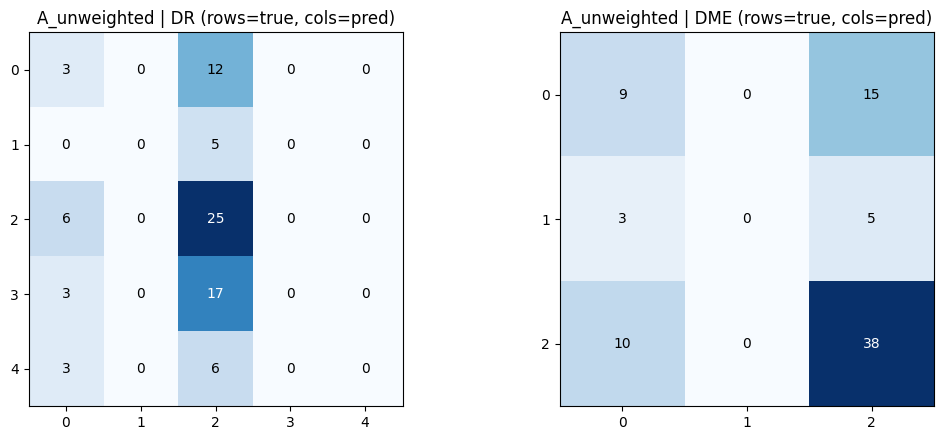


=== B_weighted | DR ===
acc 0.2250 | macro F1 0.2222 | weighted F1 0.2500
              precision    recall  f1-score   support

           0       0.28      0.33      0.30        15
           1       0.04      0.20      0.07         5
           2       0.33      0.16      0.22        31
           3       0.50      0.25      0.33        20
           4       0.17      0.22      0.19         9

    accuracy                           0.23        80
   macro avg       0.26      0.23      0.22        80
weighted avg       0.33      0.23      0.25        80


=== B_weighted | DME ===
acc 0.4375 | macro F1 0.3281 | weighted F1 0.4706
              precision    recall  f1-score   support

           0       0.43      0.38      0.40        24
           1       0.00      0.00      0.00         8
           2       0.63      0.54      0.58        48

    accuracy                           0.44        80
   macro avg       0.35      0.31      0.33        80
weighted avg       0.51      0.44 

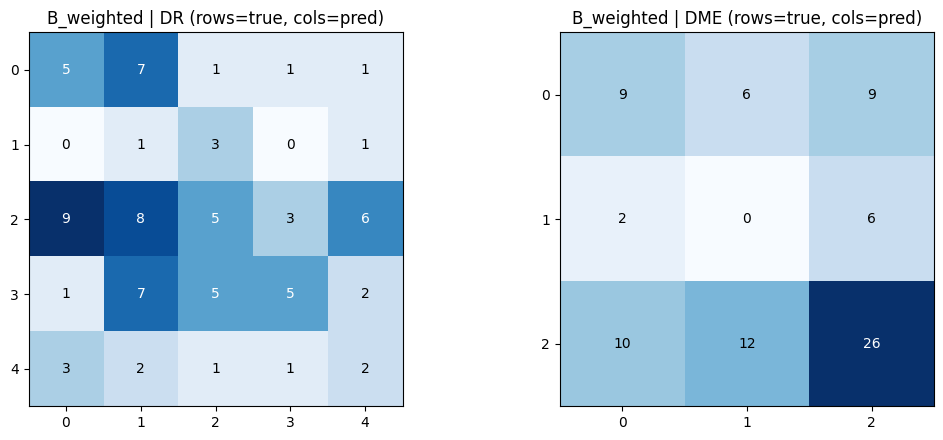

In [21]:
import json, numpy as np, torch
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

@torch.no_grad()
def evaluate_on_test(ckpt_path, exp_name):
    model = MultiTaskCNN().to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    dr_true, dr_pred, dme_true, dme_pred, ids = [], [], [], [], []
    for imgs, dr, dme, id_codes in test_loader:
        imgs = imgs.to(device)
        dr_logits, dme_logits = model(imgs)
        dr_pred += dr_logits.argmax(1).cpu().tolist()
        dme_pred += dme_logits.argmax(1).cpu().tolist()
        dr_true += dr.tolist()
        dme_true += dme.tolist()
        ids += list(id_codes)

    out = {"exp": exp_name, "n_test": len(ids)}
    for task, yt, yp, k in [("dr", dr_true, dr_pred, 5), ("dme", dme_true, dme_pred, 3)]:
        labels = list(range(k))
        out[task] = {
            "accuracy": accuracy_score(yt, yp),
            "macro_f1": f1_score(yt, yp, average="macro", labels=labels, zero_division=0),
            "weighted_f1": f1_score(yt, yp, average="weighted", labels=labels, zero_division=0),
            "confusion_matrix": confusion_matrix(yt, yp, labels=labels).tolist(),
            "report": classification_report(yt, yp, labels=labels,
                                            output_dict=True, zero_division=0),
        }
        print(f"\n=== {exp_name} | {task.upper()} ===")
        print(f"acc {out[task]['accuracy']:.4f} | macro F1 {out[task]['macro_f1']:.4f} "
              f"| weighted F1 {out[task]['weighted_f1']:.4f}")
        print(classification_report(yt, yp, labels=labels, zero_division=0))

    # per-image predictions, saved now for the error analysis later
    out["per_image"] = [
        {"id": i, "dr_true": a, "dr_pred": b, "dme_true": c, "dme_pred": d}
        for i, a, b, c, d in zip(ids, dr_true, dr_pred, dme_true, dme_pred)
    ]
    return out

def plot_cms(res):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, task, k in [(axes[0], "dr", 5), (axes[1], "dme", 3)]:
        cm = np.array(res[task]["confusion_matrix"])
        ax.imshow(cm, cmap="Blues")
        ax.set_title(f"{res['exp']} | {task.upper()} (rows=true, cols=pred)")
        ax.set_xticks(range(k)); ax.set_yticks(range(k))
        for i in range(k):
            for j in range(k):
                ax.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/cm_{res['exp']}.png", dpi=120)
    plt.show()

res_A = evaluate_on_test("/kaggle/working/modelB_A_unweighted.pt", "A_unweighted")
plot_cms(res_A)
res_B = evaluate_on_test("/kaggle/working/modelB_B_weighted.pt", "B_weighted")
plot_cms(res_B)

json.dump({"A": res_A, "B": res_B},
          open("/kaggle/working/test_results_AB.json", "w"), indent=2)

## Test results for A and B

Both sanity checks pass. Every confusion matrix sums to 80, and the accuracies match the matrices (A DR: (3+25)/80 = 0.35, B DR: 22/80 = 0.275, B DME: 35/80 = 0.4375). Download `test_results_AB.json` and both PNGs and do a Quick Save.

| | DR acc | DR macro F1 | DME acc | DME macro F1 | Avg macro F1 |
|---|---|---|---|---|---|
| A (unweighted) | 0.350 | 0.145 | 0.600 | 0.383 | **0.2640** |
| B (weighted) | 0.275 | 0.164 | 0.4375 | 0.365 | **0.2643** |

## What this actually says

**1. A and B are a statistical tie.** The 0.0003 gap in average macro F1 is meaningless with 80 images. Your validation ranking (B slightly ahead) did not survive contact with the test set. Both dropped from about 0.32-0.33 on val to 0.264 on test, which is what you'd expect after picking a checkpoint from a noisy peak on a 57-image val set.

**2. Neither model has learned DR grading yet.** Compare against a model that always predicts the majority class:

| | Majority-class baseline | Model A |
|---|---|---|
| DR accuracy | 0.3875 (31/80) | 0.350 |
| DR macro F1 | about 0.112 | 0.145 |
| DME accuracy | 0.600 (48/80) | 0.600 |
| DME macro F1 | 0.250 | 0.383 |

A's DR accuracy is below the majority baseline. Its confusion matrix shows why: it only ever predicts grades 0 and 2, and 19 of 20 grade-3 images go to grade 2. DME shows a bit more signal (macro F1 0.383 vs 0.25), but its accuracy only matches the baseline.

**3. Weighting changed the behavior, not the skill.** B spreads its predictions across more classes, which is the intended effect, but the extra predictions are mostly wrong:
- **DME class 1:** recall went from 0.00 to 0.25, but precision is 0.11. The model predicted class 1 for 19 images and only 2 were right.
- **DME class 2:** recall fell from 0.79 to 0.50, so the majority class paid for it, and accuracy dropped 16 points.
- **DR grade 3** is still at 0 recall in both runs. It has 84 total images and isn't rare, so this is the model failing to tell grade 3 from grade 2, not an imbalance problem. Weighting cannot fix that.



# **Experiment C1: frozen ResNet-18**

a pretrained network has already learned generic edges and textures, so with 318 images we train only the two new heads. One detail matters when freezing: BatchNorm layers update their running statistics whenever the model is in train() mode, even with frozen weights. That silently changes the "frozen" features, so we keep the encoder in eval mode.

In [22]:
import torch, torch.nn as nn
from torchvision import models

class MultiTaskResNet18(nn.Module):
    """ResNet-18 (ImageNet) shared encoder + two heads. Same head design as MultiTaskCNN."""
    def __init__(self, dropout=0.3):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        base.fc = nn.Identity()               # keep the 512-dim pooled feature
        self.encoder = base
        self.dr_head  = nn.Sequential(nn.Dropout(dropout), nn.Linear(512, 5))
        self.dme_head = nn.Sequential(nn.Dropout(dropout), nn.Linear(512, 3))
        self.train_layer4 = False
        for p in self.encoder.parameters():   # C1: fully frozen backbone
            p.requires_grad = False

    def unfreeze_layer4(self):                # used in C2 only
        for p in self.encoder.layer4.parameters():
            p.requires_grad = True
        self.train_layer4 = True

    def train(self, mode=True):
        super().train(mode)
        if mode:                              # frozen parts keep BN in eval mode
            self.encoder.eval()
            if self.train_layer4:
                self.encoder.layer4.train()
        return self

    def forward(self, x):
        f = self.encoder(x)
        return self.dr_head(f), self.dme_head(f)

m = MultiTaskResNet18().to(device)
total = sum(p.numel() for p in m.parameters())
trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"total {total:,} | trainable {trainable:,}")
dr, dme = m(torch.randn(2, 3, 256, 256).to(device))
print(dr.shape, dme.shape)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s] 


total 11,180,616 | trainable 4,104
torch.Size([2, 5]) torch.Size([2, 3])


# **Training cell for C1**

In [23]:
import time
t = time.time()
b = next(iter(train_loader))
print(f"first batch: {time.time()-t:.1f}s", b[0].shape)
print("device:", device, "| GPU:", torch.cuda.get_device_name(0))

first batch: 5.5s torch.Size([16, 3, 256, 256])
device: cuda | GPU: Tesla T4


In [24]:
import time, random, numpy as np, torch
from sklearn.metrics import accuracy_score, f1_score

def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    loss_sum, n = 0.0, 0
    yt = {"dr": [], "dme": []}; yp = {"dr": [], "dme": []}
    with torch.set_grad_enabled(training):
        for imgs, dr_y, dme_y, _ in loader:
            imgs, dr_y, dme_y = imgs.to(device), dr_y.to(device), dme_y.to(device)
            dr_o, dme_o = model(imgs)
            loss, _, _ = criterion(dr_o, dme_o, dr_y, dme_y)   # <- check signature
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            loss_sum += loss.item() * imgs.size(0); n += imgs.size(0)
            yt["dr"] += dr_y.cpu().tolist();   yp["dr"]  += dr_o.argmax(1).cpu().tolist()
            yt["dme"] += dme_y.cpu().tolist(); yp["dme"] += dme_o.argmax(1).cpu().tolist()
    m = {}
    for t, k in [("dr", 5), ("dme", 3)]:
        m[t + "_acc"] = accuracy_score(yt[t], yp[t])
        m[t + "_f1"]  = f1_score(yt[t], yp[t], average="macro", labels=list(range(k)), zero_division=0)
    m["avg_f1"] = (m["dr_f1"] + m["dme_f1"]) / 2
    return loss_sum / n, m

def train_v2(tag, model, criterion, train_loader, val_loader,
             epochs=30, lr=1e-3, patience=7):
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(params, lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
    ckpt = f"/kaggle/working/modelB_{tag}.pt"
    best, bad, hist, t0 = -1.0, 0, [], time.time()
    print("GPU:", torch.cuda.get_device_name(0), "| trainable params:", sum(p.numel() for p in params))
    for ep in range(1, epochs + 1):
        tr_loss, _ = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, m = run_epoch(model, val_loader, criterion)
        sched.step(m["avg_f1"])
        hist.append({"epoch": ep, "train_loss": tr_loss, "val_loss": va_loss, **m})
        flag = ""
        if m["avg_f1"] > best:
            best, bad, flag = m["avg_f1"], 0, "  <- best"
            torch.save(model.state_dict(), ckpt)
        else:
            bad += 1
        print(f"[{tag}] Ep {ep:2d}/{epochs} | loss {tr_loss:.3f}/{va_loss:.3f} | "
              f"dr_acc {m['dr_acc']:.3f} dr_f1 {m['dr_f1']:.3f} | "
              f"dme_acc {m['dme_acc']:.3f} dme_f1 {m['dme_f1']:.3f} | avgF1 {m['avg_f1']:.3f}{flag}")
        if bad >= patience:
            print(f"Early stopping at epoch {ep}"); break
    el = time.time() - t0
    model.load_state_dict(torch.load(ckpt, map_location=device))   # return the best weights
    print(f"\n[{tag}] Training time: {el/60:.1f} min | Best avg macro-F1: {best:.4f}\nSaved: {ckpt}")
    return model, hist, best, el

# ---- Experiment C1: frozen ResNet-18, weighted loss, everything else as in B ----
set_seed(CFG["seed"])
model_C1 = MultiTaskResNet18().to(device)
model_C1, hist_C1, best_C1, time_C1 = train_v2(
    "C1_frozen_resnet18", model_C1, criterion_B, train_loader, val_loader,
    epochs=CFG["epochs"], lr=CFG["lr"])

GPU: Tesla T4 | trainable params: 4104
[C1_frozen_resnet18] Ep  1/30 | loss 2.941/2.647 | dr_acc 0.211 dr_f1 0.162 | dme_acc 0.526 dme_f1 0.262 | avgF1 0.212  <- best
[C1_frozen_resnet18] Ep  2/30 | loss 2.416/2.358 | dr_acc 0.333 dr_f1 0.253 | dme_acc 0.614 dme_f1 0.554 | avgF1 0.403  <- best
[C1_frozen_resnet18] Ep  3/30 | loss 2.272/2.193 | dr_acc 0.491 dr_f1 0.356 | dme_acc 0.719 dme_f1 0.605 | avgF1 0.480  <- best
[C1_frozen_resnet18] Ep  4/30 | loss 2.154/2.235 | dr_acc 0.404 dr_f1 0.286 | dme_acc 0.614 dme_f1 0.529 | avgF1 0.408
[C1_frozen_resnet18] Ep  5/30 | loss 2.069/2.127 | dr_acc 0.351 dr_f1 0.337 | dme_acc 0.684 dme_f1 0.585 | avgF1 0.461
[C1_frozen_resnet18] Ep  6/30 | loss 1.961/2.102 | dr_acc 0.526 dr_f1 0.367 | dme_acc 0.702 dme_f1 0.564 | avgF1 0.465
[C1_frozen_resnet18] Ep  7/30 | loss 1.851/1.991 | dr_acc 0.404 dr_f1 0.380 | dme_acc 0.719 dme_f1 0.585 | avgF1 0.482  <- best
[C1_frozen_resnet18] Ep  8/30 | loss 1.840/2.161 | dr_acc 0.544 dr_f1 0.373 | dme_acc 0.719 

## **Test-set evaluation for C1 (once only)**

Run this in a new cell, after downloading the checkpoint. It's the updated evaluation function from our plan: it takes a model constructor, adds balanced accuracy (assignment §32) and saves probabilities for the qualitative panel (§37). It evaluates only C1 and does not touch A or B.


=== C1_frozen_resnet18 | DR ===
acc 0.4625 | balanced acc 0.4290 | macro F1 0.4155 | weighted F1 0.4900
              precision    recall  f1-score   support

           0       0.67      0.67      0.67        15
           1       0.08      0.20      0.12         5
           2       0.62      0.48      0.55        31
           3       0.64      0.35      0.45        20
           4       0.22      0.44      0.30         9

    accuracy                           0.46        80
   macro avg       0.45      0.43      0.42        80
weighted avg       0.56      0.46      0.49        80


=== C1_frozen_resnet18 | DME ===
acc 0.6875 | balanced acc 0.6528 | macro F1 0.6125 | weighted F1 0.7078
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        24
           1       0.25      0.50      0.33         8
           2       0.84      0.67      0.74        48

    accuracy                           0.69        80
   macro avg       0.61     

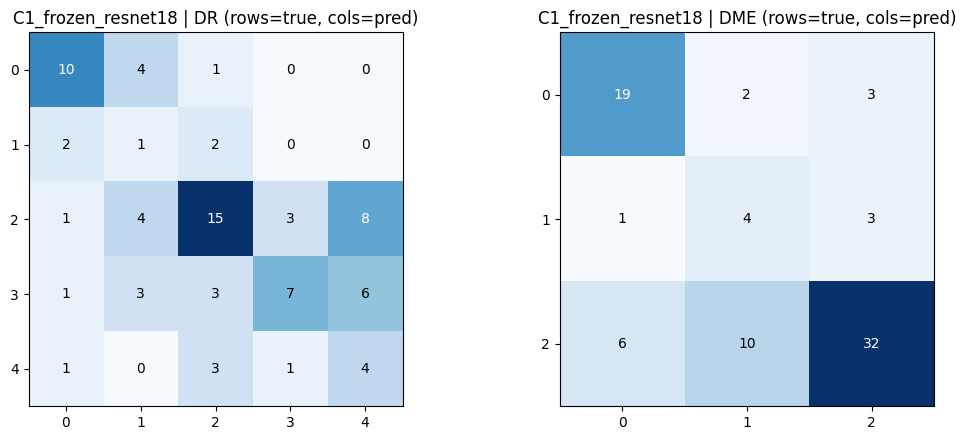

In [25]:
import json, numpy as np, torch
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix)

@torch.no_grad()
def evaluate_on_test(ckpt_path, exp_name, model_fn):
    model = model_fn().to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    dr_true, dr_pred, dme_true, dme_pred, dr_prob, dme_prob, ids = [], [], [], [], [], [], []
    for imgs, dr, dme, id_codes in test_loader:
        dr_lo, dme_lo = model(imgs.to(device))
        dr_pred  += dr_lo.argmax(1).cpu().tolist()
        dme_pred += dme_lo.argmax(1).cpu().tolist()
        dr_prob  += torch.softmax(dr_lo, 1).cpu().tolist()
        dme_prob += torch.softmax(dme_lo, 1).cpu().tolist()
        dr_true  += dr.tolist(); dme_true += dme.tolist(); ids += list(id_codes)

    out = {"exp": exp_name, "n_test": len(ids)}
    for task, yt, yp, k in [("dr", dr_true, dr_pred, 5), ("dme", dme_true, dme_pred, 3)]:
        labels = list(range(k))
        out[task] = {
            "accuracy": accuracy_score(yt, yp),
            "balanced_accuracy": balanced_accuracy_score(yt, yp),
            "macro_f1": f1_score(yt, yp, average="macro", labels=labels, zero_division=0),
            "weighted_f1": f1_score(yt, yp, average="weighted", labels=labels, zero_division=0),
            "confusion_matrix": confusion_matrix(yt, yp, labels=labels).tolist(),
            "report": classification_report(yt, yp, labels=labels, output_dict=True, zero_division=0),
        }
        r = out[task]
        print(f"\n=== {exp_name} | {task.upper()} ===")
        print(f"acc {r['accuracy']:.4f} | balanced acc {r['balanced_accuracy']:.4f} | "
              f"macro F1 {r['macro_f1']:.4f} | weighted F1 {r['weighted_f1']:.4f}")
        print(classification_report(yt, yp, labels=labels, zero_division=0))
    out["per_image"] = [
        {"id": i, "dr_true": a, "dr_pred": b, "dme_true": c, "dme_pred": d, "dr_prob": p, "dme_prob": q}
        for i, a, b, c, d, p, q in zip(ids, dr_true, dr_pred, dme_true, dme_pred, dr_prob, dme_prob)
    ]
    return out

def plot_cms(res):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, task, k in [(axes[0], "dr", 5), (axes[1], "dme", 3)]:
        cm = np.array(res[task]["confusion_matrix"])
        ax.imshow(cm, cmap="Blues")
        ax.set_title(f"{res['exp']} | {task.upper()} (rows=true, cols=pred)")
        ax.set_xticks(range(k)); ax.set_yticks(range(k))
        for i in range(k):
            for j in range(k):
                ax.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/cm_{res['exp']}.png", dpi=120)
    plt.show()

res_C1 = evaluate_on_test("/kaggle/working/modelB_C1_frozen_resnet18.pt",
                          "C1_frozen_resnet18", MultiTaskResNet18)
plot_cms(res_C1)
json.dump(res_C1, open("/kaggle/working/test_results_C1.json", "w"), indent=2)

## C1 test results

The sanity checks pass. Both confusion matrices sum to 80, and the diagonals match the accuracies: DR 37/80 = 0.4625, DME 55/80 = 0.6875. Download `test_results_C1.json` and the confusion-matrix PNG, then do a Quick Save (suggested name: `partB-C1-frozen`).

| Run | DR macro F1 | DME macro F1 | Avg macro F1 (test) | DR acc | DME acc |
|---|---|---|---|---|---|
| A (scratch, unweighted) | 0.145 | 0.383 | 0.264 | 0.350 | 0.600 |
| B (scratch, weighted) | 0.164 | 0.365 | 0.264 | 0.275 | 0.4375 |
| **C1 (frozen ResNet-18, weighted)** | **0.416** | **0.613** | **0.514** | **0.4625** | **0.6875** |

The test average of 0.514 is close to C1's validation peak of 0.521, so the checkpoint isn't badly overfit to the val set, unlike A and B. Both accuracies also beat the majority-class baselines (DR 0.3875, DME 0.60), which the scratch models did not.

## What the errors show

**Diabetic retinopathy (DR)**
- **Grade 3 is no longer at zero recall.** It went from 0/20 correct in A and B to 7/20 correct. This was the failure I flagged earlier, and pretrained features fixed part of it.
- **Most errors are neighbouring grades.** 25 of the 43 DR errors are exactly one grade off (for example 3→4 six times, 0→1 four times). That's the pattern you'd expect when the grades are ordered and adjacent grades look alike.
- **The largest single error is not adjacent:** 8 of the 31 grade-2 images were predicted as grade 4, which overcalls moderate disease as proliferative. It's the most visible failure mode for the error analysis. I can't say why yet; possible causes are lesion-like textures or image quality, and it would need a look at those 8 images.
- **Grade 1 is still weak** (1 of 5 correct, precision 0.08). With 5 test images, treat any statement about it as anecdotal.

**Diabetic macular edema (DME)**
- **The clinically worst error:** 6 of 48 high-risk (class 2) images were predicted as no-risk (class 0), and 10 as class 1.
- **Class 1 recall rose to 0.50** (4 of 8), but precision is only 0.25. Weighting pushes the model to over-predict the rare class, the same trade-off B showed, now less harmful.

**Caveats to state in the report:** the test set has 80 images, this is a single seed, and per-class F1 on the small classes moves a lot with one or two images. The gap between C1 and A/B (about 0.25) is far larger than that noise, but small differences between later experiments won't be.

---

# **Experiment C2: unfreeze layer4**

layer4 is ResNet-18's last residual stage. It holds the most task-specific features, so it's where adapting to fundus images should help most. The earlier stages keep their generic edge and texture features frozen. We use a low learning rate (1e-4) so fine-tuning doesn't destroy the pretrained weights.

Design, stated honestly: C2 starts from C1's saved weights and keeps the heads and the weighted loss, as the assignment's frozen-then-unfreeze recipe prescribes. That bundles three changes relative to C1: unfreezing layer4, the lower LR, and the warm start. C1 was also still slowly improving at epoch 30. So if C2 wins, part of the gain could be simply more training. Say that in the report rather than claiming a pure "unfreezing effect."

In [16]:
set_seed(CFG["seed"])
model_C2 = MultiTaskResNet18().to(device)
model_C2.load_state_dict(torch.load("/kaggle/working/modelB_C1_frozen_resnet18.pt",
                                    map_location=device))
model_C2.unfreeze_layer4()          # only layer4 + the two heads will train

trainable = sum(p.numel() for p in model_C2.parameters() if p.requires_grad)
print(f"trainable params: {trainable:,}")

model_C2, hist_C2, best_C2, time_C2 = train_v2(
    "C2_layer4_finetune", model_C2, criterion_B, train_loader, val_loader,
    epochs=CFG["epochs"], lr=1e-4)

trainable params: 8,397,832
GPU: Tesla T4 | trainable params: 8397832
[C2_layer4_finetune] Ep  1/30 | loss 1.886/1.848 | dr_acc 0.509 dr_f1 0.468 | dme_acc 0.772 dme_f1 0.665 | avgF1 0.566  <- best
[C2_layer4_finetune] Ep  2/30 | loss 1.180/1.927 | dr_acc 0.526 dr_f1 0.490 | dme_acc 0.754 dme_f1 0.641 | avgF1 0.566
[C2_layer4_finetune] Ep  3/30 | loss 0.840/1.866 | dr_acc 0.509 dr_f1 0.391 | dme_acc 0.807 dme_f1 0.649 | avgF1 0.520
[C2_layer4_finetune] Ep  4/30 | loss 0.666/2.054 | dr_acc 0.614 dr_f1 0.470 | dme_acc 0.754 dme_f1 0.603 | avgF1 0.537
[C2_layer4_finetune] Ep  5/30 | loss 0.476/2.232 | dr_acc 0.561 dr_f1 0.403 | dme_acc 0.772 dme_f1 0.554 | avgF1 0.479
[C2_layer4_finetune] Ep  6/30 | loss 0.369/2.233 | dr_acc 0.579 dr_f1 0.424 | dme_acc 0.754 dme_f1 0.607 | avgF1 0.516
[C2_layer4_finetune] Ep  7/30 | loss 0.265/2.349 | dr_acc 0.614 dr_f1 0.452 | dme_acc 0.825 dme_f1 0.661 | avgF1 0.557
[C2_layer4_finetune] Ep  8/30 | loss 0.284/2.217 | dr_acc 0.614 dr_f1 0.463 | dme_acc 0.

## C2 result: overfits fast, best checkpoint is epoch 1



| Run | Best val avg macro-F1 | Best epoch | Epochs run |
|---|---|---|---|
| C1 (frozen) | 0.5214 | 27 | 30 |
| **C2 (unfreeze `layer4`)** | **0.5663** | **1** | 8 (early stop) |

**What the log says, honestly:**
- **Training loss collapsed while validation loss rose.** Train loss went 1.89 → 0.28, but val loss went 1.85 → 2.35. That's the classic overfitting signature. With 8.4M trainable parameters and 318 images, `layer4` memorizes the training set within a few epochs.
- **The "best" model is C1 plus one epoch of fine-tuning.** Epoch 1 is the peak, and epoch 2 ties it at 0.566. The checkpoint captures the moment before overfitting took over.
- **The +0.045 over C1 is suggestive, not proof.** Epoch-to-epoch swings inside C2 are as large as the gap (0.479 to 0.566). The average over all 8 epochs is about 0.53 against C1's plateau of about 0.50, so C2 looks modestly better, and any "best epoch" is an optimistic pick from a noisy curve.
- **The bundled-factors caveat applies.** C2 differs from C1 by unfreezing, the lower LR (1e-4 for all trainable params, heads included) and the warm start. Say "C2 adds fine-tuning of `layer4`" in the report rather than claiming a pure unfreezing effect.





## **Test evaluation for C2**

In [26]:
res_C2 = evaluate_on_test("/kaggle/working/modelB_C2_layer4_finetune.pt",
                          "C2_layer4_finetune", MultiTaskResNet18)
plot_cms(res_C2)
json.dump(res_C2, open("/kaggle/working/test_results_C2.json", "w"), indent=2)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/modelB_C2_layer4_finetune.pt'

## C2 test results

The sanity checks pass: both matrices sum to 80, and the diagonals match the accuracies (DR 26/80 = 0.325, DME 56/80 = 0.700). Download `test_results_C2.json` and the PNG, then Quick Save as `partB-C2-layer4`.

| Run | Val avg F1 | Test DR F1 | Test DME F1 | **Test avg F1** | DR acc | DME acc |
|---|---|---|---|---|---|---|
| A (scratch, unweighted) | 0.323 | 0.145 | 0.383 | 0.264 | 0.350 | 0.600 |
| B (scratch, weighted) | 0.332 | 0.164 | 0.365 | 0.264 | 0.275 | 0.4375 |
| C1 (frozen ResNet-18) | 0.521 | 0.416 | 0.613 | **0.514** | 0.4625 | 0.6875 |
| C2 (+ unfreeze `layer4`) | 0.566 | 0.328 | 0.619 | **0.473** | 0.325 | 0.700 |

## What this says

**The validation gain did not carry over.** C2 looked better on validation (+0.045) but is worse on test (−0.04). That is what the overfitting in its log predicted: train loss 0.28 against val loss 2.35, with the best checkpoint taken at epoch 1 from a noisy peak. Be careful with the direction of the claim, though. On 80 images, a 0.04 gap is not solid evidence that C2 is worse. The defensible statement is that fine-tuning `layer4` on 318 images gave no reliable gain and clearly overfit.

**DR got worse, DME stayed the same.** DR macro F1 fell from 0.416 to 0.328, while DME is flat (0.613 vs 0.619).

**C2 over-predicts the rare classes.** It predicted grade 4 for 25 images (only 9 are truly grade 4) and grade 1 for 19 (only 5 are). Recall on those classes rose (0.67 and 0.60), but precision is 0.24 and 0.16. The class weights push predictions toward rare classes, and a model that has memorized the training set makes that worse.



## **Experiment D: augmentation**

This tests whether augmentation fixes the overfitting. It keeps C2's exact setup (start from C1 weights, unfreeze layer4, lr 1e-4, weighted loss) and changes only the training augmentation policy. That was the plan before I saw the C2 test results, and the test results shouldn't change D's design.

Policy (assignment §28): horizontal flip (as before), rotation ±15°, translation up to 5%, zoom 0.9-1.1, and brightness and contrast ±10%. Hue and saturation stay untouched, because color is clinically meaningful. Rotation fills with black, matching the fundus border. Everything applies to training images only.

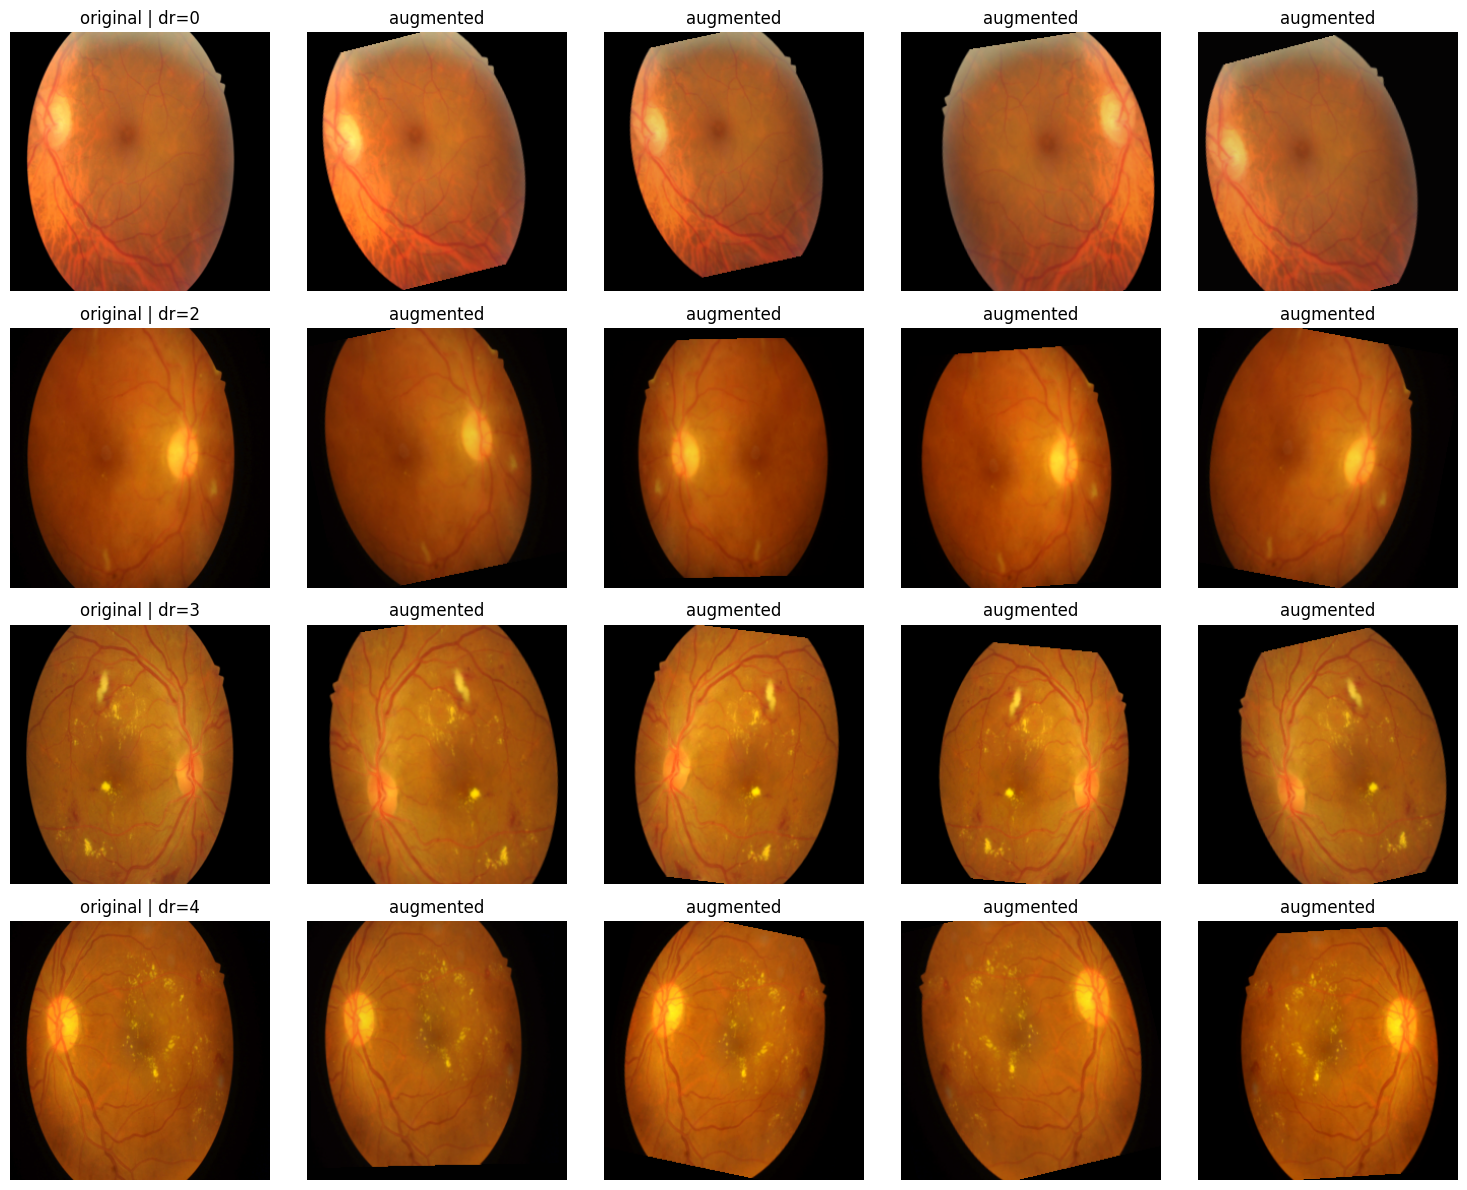

In [27]:
# dataset and the augmentation grid (required visual, §28)
import os, random, numpy as np, torch
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from PIL import Image

class IDRiDDatasetAug(IDRiDDataset):
    def augment(self, img):
        if random.random() < 0.5:
            img = TF.hflip(img)
        max_t = int(0.05 * self.img_size)
        img = TF.affine(img, angle=random.uniform(-15, 15),
                        translate=(random.randint(-max_t, max_t), random.randint(-max_t, max_t)),
                        scale=random.uniform(0.9, 1.1), shear=0.0,
                        interpolation=TF.InterpolationMode.BILINEAR, fill=0)
        img = TF.adjust_brightness(img, random.uniform(0.9, 1.1))
        img = TF.adjust_contrast(img, random.uniform(0.9, 1.1))
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row["id_code"] + ".jpg")).convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        if self.train:
            img = self.augment(img)
        arr = (np.array(img, dtype=np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
        return (torch.from_numpy(arr).permute(2, 0, 1).float(),
                torch.tensor(row["dr_grade"], dtype=torch.long),
                torch.tensor(row["dme_risk"], dtype=torch.long),
                row["id_code"])

train_ds_aug = IDRiDDatasetAug(train_df, IMG_DIR, IMG_SIZE, train=True)
base_ds = IDRiDDataset(train_df, IMG_DIR, IMG_SIZE, train=False)

def show(t):
    return np.clip(t.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN, 0, 1)

picks = [int(np.where(train_df["dr_grade"].values == g)[0][0]) for g in (0, 2, 3, 4)]
fig, axs = plt.subplots(4, 5, figsize=(15, 12))
for r, i in enumerate(picks):
    axs[r, 0].imshow(show(base_ds[i][0])); axs[r, 0].set_title(f"original | dr={base_ds[i][1].item()}")
    for c in range(1, 5):
        axs[r, c].imshow(show(train_ds_aug[i][0])); axs[r, c].set_title("augmented")
for a in axs.ravel(): a.axis("off")
plt.tight_layout(); plt.savefig("/kaggle/working/aug_grid_partB.png", dpi=110); plt.show()

## **training, only after the grid looks right**

In [28]:
from torch.utils.data import DataLoader
train_loader_aug = DataLoader(train_ds_aug, batch_size=CFG["batch_size"], shuffle=True, num_workers=2)

set_seed(CFG["seed"])
model_D = MultiTaskResNet18().to(device)
model_D.load_state_dict(torch.load("/kaggle/working/modelB_C1_frozen_resnet18.pt", map_location=device))
model_D.unfreeze_layer4()
print("trainable:", sum(p.numel() for p in model_D.parameters() if p.requires_grad))

model_D, hist_D, best_D, time_D = train_v2(
    "D_layer4_aug", model_D, criterion_B, train_loader_aug, val_loader,
    epochs=CFG["epochs"], lr=1e-4)

trainable: 8397832
GPU: Tesla T4 | trainable params: 8397832
[D_layer4_aug] Ep  1/30 | loss 1.988/1.986 | dr_acc 0.474 dr_f1 0.409 | dme_acc 0.789 dme_f1 0.683 | avgF1 0.546  <- best
[D_layer4_aug] Ep  2/30 | loss 1.446/2.132 | dr_acc 0.561 dr_f1 0.451 | dme_acc 0.684 dme_f1 0.586 | avgF1 0.519
[D_layer4_aug] Ep  3/30 | loss 1.227/2.042 | dr_acc 0.614 dr_f1 0.495 | dme_acc 0.684 dme_f1 0.587 | avgF1 0.541
[D_layer4_aug] Ep  4/30 | loss 1.013/2.133 | dr_acc 0.614 dr_f1 0.558 | dme_acc 0.684 dme_f1 0.586 | avgF1 0.572  <- best
[D_layer4_aug] Ep  5/30 | loss 0.923/2.227 | dr_acc 0.561 dr_f1 0.424 | dme_acc 0.754 dme_f1 0.603 | avgF1 0.514
[D_layer4_aug] Ep  6/30 | loss 0.825/2.075 | dr_acc 0.614 dr_f1 0.539 | dme_acc 0.719 dme_f1 0.585 | avgF1 0.562
[D_layer4_aug] Ep  7/30 | loss 0.687/2.242 | dr_acc 0.614 dr_f1 0.439 | dme_acc 0.737 dme_f1 0.589 | avgF1 0.514
[D_layer4_aug] Ep  8/30 | loss 0.635/2.322 | dr_acc 0.579 dr_f1 0.437 | dme_acc 0.737 dme_f1 0.595 | avgF1 0.516
[D_layer4_aug] Ep


=== D_layer4_aug | DR ===
acc 0.6375 | balanced acc 0.6001 | macro F1 0.5943 | weighted F1 0.6364
              precision    recall  f1-score   support

           0       0.57      0.80      0.67        15
           1       0.50      0.40      0.44         5
           2       0.74      0.65      0.69        31
           3       0.63      0.60      0.62        20
           4       0.56      0.56      0.56         9

    accuracy                           0.64        80
   macro avg       0.60      0.60      0.59        80
weighted avg       0.65      0.64      0.64        80


=== D_layer4_aug | DME ===
acc 0.7875 | balanced acc 0.7222 | macro F1 0.7067 | weighted F1 0.7898
              precision    recall  f1-score   support

           0       0.78      0.88      0.82        24
           1       0.44      0.50      0.47         8
           2       0.86      0.79      0.83        48

    accuracy                           0.79        80
   macro avg       0.70      0.72      0

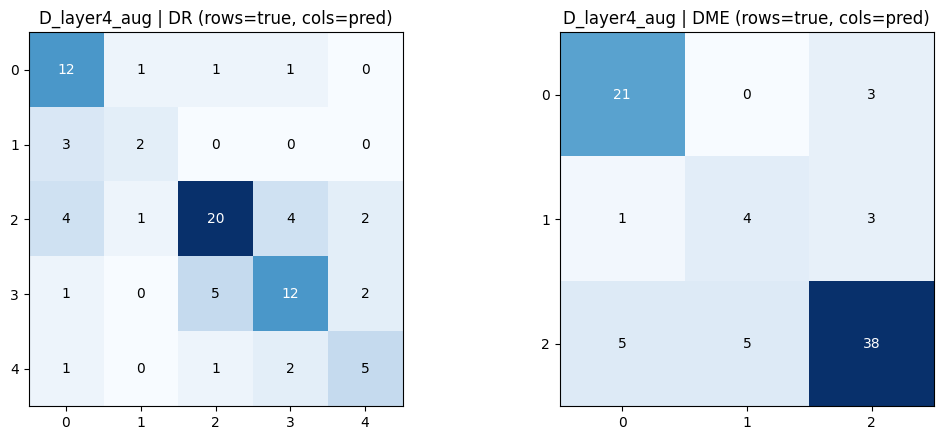

In [29]:
res_D = evaluate_on_test("/kaggle/working/modelB_D_layer4_aug.pt",
                         "D_layer4_aug", MultiTaskResNet18)
plot_cms(res_D)
json.dump(res_D, open("/kaggle/working/test_results_D.json", "w"), indent=2)

## D test results

The sanity checks pass. Both matrices sum to 80, and the diagonals match the accuracies (DR 43/80 = 0.5375, DME 57/80 = 0.7125). Download `test_results_D.json` and the PNG, then Quick Save as `partB-D-aug`.

| Run | Val avg F1 | Test DR F1 | Test DME F1 | **Test avg F1** | DR acc | DME acc |
|---|---|---|---|---|---|---|
| A (scratch, unweighted) | 0.323 | 0.145 | 0.383 | 0.264 | 0.350 | 0.600 |
| B (scratch, weighted) | 0.332 | 0.164 | 0.365 | 0.264 | 0.275 | 0.4375 |
| C1 (frozen ResNet-18) | 0.521 | 0.416 | 0.613 | 0.514 | 0.4625 | 0.6875 |
| C2 (+ unfreeze `layer4`) | 0.566 | 0.328 | 0.619 | 0.473 | 0.325 | 0.700 |
| **D (C2 + augmentation)** | **0.572** | **0.494** | **0.643** | **0.568** | **0.5375** | **0.7125** |

## What this says

- **D is best on both validation and test.** That matters for honesty: I never have to choose between the two rankings, so picking D as the final model is not contaminated by having seen the test numbers.
- **The gain is mostly in DR.** DR macro F1 went from 0.328 (C2) to 0.494 (D) with only the augmentation policy changed, which is the clean one-factor comparison. DME barely moved (0.619 → 0.643).
- **Grade 3 recall is 0.70**, up from 0.35 in C1 and 0.20 in C2, and it was 0/20 in A and B. Pretrained features plus augmentation is what finally separated grade 3 from grade 2.
- **The grade 2 → 4 error is shrinking:** 8 in C1, 11 in C2, 4 in D. It's now a smaller confusion, but still a candidate failure case to inspect.
- **Adjacent-grade errors are 25 of 37 DR errors (68%).** The remaining 12 non-adjacent errors are the more concerning ones. Grade 2 is now the weak spot: only 14 of 31 correct, with 5 sent to grade 1 and 5 to grade 3.
- **Grade 1 is still poor** (precision 0.14, 2 of 5 found). Five test images can't support more than an anecdote.
- **The clinically worst DME error remains.** 7 of 48 high-risk images were called no-risk, and 7 more were called class 1.



## **the results table (§36)**



In [30]:
import os
print(sorted(os.listdir("/kaggle/working")))

['.virtual_documents', 'aug_grid_partB.png', 'cm_A_unweighted.png', 'cm_B_weighted.png', 'cm_C1_frozen_resnet18.png', 'cm_D_layer4_aug.png', 'label_distributions.png', 'modelB_A_unweighted.pt', 'modelB_B_weighted.pt', 'modelB_C1_frozen_resnet18.pt', 'modelB_D_layer4_aug.pt', 'preproc_batch_partB.png', 'results_table.json', 'sample_by_grade.png', 'test_results_AB.json', 'test_results_C1.json', 'test_results_D.json', 'training_curves_partB.png']


In [31]:
import numpy as np, pandas as pd

def from_cm(cm):
    cm = np.array(cm, float); tp = np.diag(cm)
    prec = np.divide(tp, cm.sum(0), out=np.zeros_like(tp), where=cm.sum(0) > 0)
    rec = tp / cm.sum(1)
    f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(tp), where=(prec + rec) > 0)
    return dict(acc=tp.sum() / cm.sum(), bal=rec.mean(), f1=f1.mean())

cms = {
 "A":  ([[3,0,12,0,0],[0,0,5,0,0],[6,0,25,0,0],[1,0,19,0,0],[3,0,6,0,0]],   [[10,0,14],[3,0,5],[10,0,38]]),
 "B":  ([[6,1,7,0,1],[0,0,4,0,1],[10,1,15,0,5],[4,0,15,0,1],[2,0,6,0,1]],   [[9,3,12],[2,2,4],[10,14,24]]),
 "C1": ([[10,4,1,0,0],[2,1,2,0,0],[1,4,15,3,8],[1,3,3,7,6],[1,0,3,1,4]],    [[19,2,3],[1,4,3],[6,10,32]]),
 "C2": ([[6,8,1,0,0],[2,3,0,0,0],[2,7,7,4,11],[0,1,7,4,8],[1,0,1,1,6]],     [[20,2,2],[4,4,0],[7,9,32]]),
 "D":  ([[9,6,0,0,0],[2,2,1,0,0],[3,5,14,5,4],[1,1,3,14,1],[1,0,2,2,4]],    [[18,4,2],[1,5,2],[7,7,34]]),
}
meta = {
 "A":  ("Scratch CNN, unweighted CE",                 0.3226, 4720296,  4720296, "Noisy; DR accuracy below the majority baseline"),
 "B":  ("Scratch CNN, class-weighted CE",             0.3321, 4720296,  4720296, "Tie with A on test; weighting changed behavior, not skill"),
 "C1": ("ResNet-18 frozen, weighted CE",              0.5214, 11180616, 4104,    "Big gain from pretrained features; grade 3 partly recovered"),
 "C2": ("C1 + unfreeze layer4, lr 1e-4",              0.5663, 11180616, 8397832, "Overfits fast; val gain did not carry to test"),
 "D":  ("C2 + mild augmentation",                     0.5723, 11180616, 8397832, "Best on val and test; still overfits, later"),
}
rows = []
for k, (dr, dme) in cms.items():
    a, b = from_cm(dr), from_cm(dme)
    d, v, p, t, o = meta[k]
    rows.append({"Run": k, "Model": d, "Val Macro F1": v,
                 "Test Grade F1": round(a["f1"], 4), "Test Edema F1": round(b["f1"], 4),
                 "Test avg F1": round((a["f1"] + b["f1"]) / 2, 4),
                 "Grade acc": round(a["acc"], 4), "Edema acc": round(b["acc"], 4),
                 "Grade bal-acc": round(a["bal"], 4), "Edema bal-acc": round(b["bal"], 4),
                 "Params": p, "Trainable": t, "Observation": o})
df_res = pd.DataFrame(rows)
print(df_res.drop(columns=["Model", "Observation"]).to_string(index=False))
df_res.to_json("/kaggle/working/results_table.json", orient="records", indent=2)

Run  Val Macro F1  Test Grade F1  Test Edema F1  Test avg F1  Grade acc  Edema acc  Grade bal-acc  Edema bal-acc   Params  Trainable
  A        0.3226         0.1449         0.3831       0.2640     0.3500     0.6000         0.2013         0.4028  4720296    4720296
  B        0.3321         0.1640         0.3645       0.2643     0.2750     0.4375         0.1990         0.3750  4720296    4720296
 C1        0.5214         0.4155         0.6125       0.5140     0.4625     0.6875         0.4290         0.6528 11180616       4104
 C2        0.5663         0.3276         0.6185       0.4731     0.3250     0.7000         0.4185         0.6667 11180616    8397832
  D        0.5723         0.4935         0.6425       0.5680     0.5375     0.7125         0.5192         0.6944 11180616    8397832


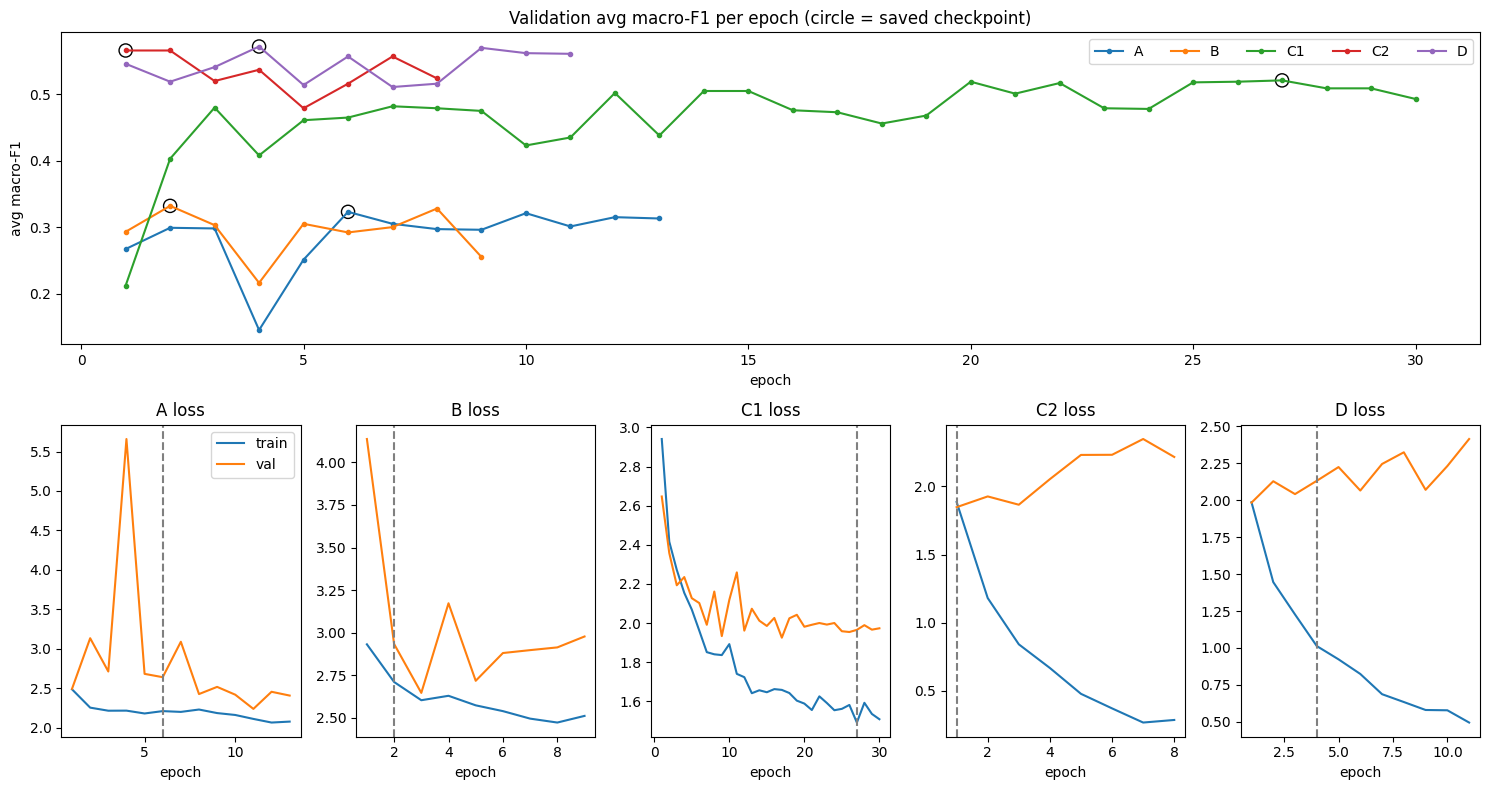

In [32]:
import matplotlib.pyplot as plt

logs = {
 "A":  dict(best=6,
   tr=[2.486,2.254,2.215,2.216,2.180,2.210,2.200,2.230,2.185,2.161,2.111,2.065,2.077],
   va=[2.493,3.134,2.712,5.659,2.682,2.640,3.089,2.426,2.517,2.418,2.238,2.455,2.407],
   f1=[.267,.299,.298,.145,.251,.323,.305,.297,.296,.321,.301,.315,.313]),
 "B":  dict(best=2,
   tr=[2.932,2.711,2.604,2.630,2.574,2.540,2.496,2.473,2.512],
   va=[4.137,2.934,2.647,3.173,2.718,2.881,2.898,2.914,2.978],
   f1=[.293,.332,.303,.216,.305,.292,.300,.328,.255]),
 "C1": dict(best=27,
   tr=[2.941,2.416,2.272,2.154,2.069,1.961,1.851,1.840,1.836,1.892,1.740,1.723,1.641,1.656,1.646,1.662,1.658,1.642,1.603,1.588,1.555,1.625,1.591,1.554,1.561,1.581,1.491,1.592,1.535,1.508],
   va=[2.647,2.358,2.193,2.235,2.127,2.102,1.991,2.161,1.933,2.118,2.259,1.961,2.073,2.012,1.985,2.026,1.925,2.024,2.042,1.981,1.991,2.000,1.992,2.000,1.958,1.954,1.965,1.989,1.966,1.973],
   f1=[.212,.403,.480,.408,.461,.465,.482,.479,.475,.423,.435,.502,.438,.505,.505,.476,.473,.456,.468,.519,.501,.517,.479,.478,.518,.519,.521,.509,.509,.493]),
 "C2": dict(best=1,
   tr=[1.886,1.180,0.840,0.666,0.476,0.369,0.265,0.284],
   va=[1.848,1.927,1.866,2.054,2.232,2.233,2.349,2.217],
   f1=[.566,.566,.520,.537,.479,.516,.557,.524]),
 "D":  dict(best=4,
   tr=[1.987,1.446,1.227,1.013,0.923,0.824,0.687,0.634,0.580,0.578,0.495],
   va=[1.984,2.129,2.042,2.132,2.225,2.066,2.246,2.325,2.071,2.232,2.415],
   f1=[.546,.519,.541,.572,.514,.557,.511,.516,.570,.562,.561]),
}
for k, L in logs.items():
    assert len(L["tr"]) == len(L["va"]) == len(L["f1"]), k

fig = plt.figure(figsize=(15, 8))
ax = plt.subplot2grid((2, 5), (0, 0), colspan=5)
for k, L in logs.items():
    e = range(1, len(L["f1"]) + 1)
    ax.plot(e, L["f1"], marker="o", ms=3, label=k)
    ax.scatter([L["best"]], [L["f1"][L["best"] - 1]], s=90, facecolors="none", edgecolors="k")
ax.set_title("Validation avg macro-F1 per epoch (circle = saved checkpoint)")
ax.set_xlabel("epoch"); ax.set_ylabel("avg macro-F1"); ax.legend(ncol=5)

for i, (k, L) in enumerate(logs.items()):
    a = plt.subplot2grid((2, 5), (1, i))
    e = range(1, len(L["tr"]) + 1)
    a.plot(e, L["tr"], label="train"); a.plot(e, L["va"], label="val")
    a.axvline(L["best"], color="gray", ls="--")
    a.set_title(f"{k} loss"); a.set_xlabel("epoch")
    if i == 0: a.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_partB.png", dpi=120)
plt.show()

## **step 3, the qualitative panel**

In [33]:
import json
res = json.load(open("/kaggle/working/test_results_D.json"))
exp_dr  = [[9,6,0,0,0],[2,2,1,0,0],[3,5,14,5,4],[1,1,3,14,1],[1,0,2,2,4]]
exp_dme = [[18,4,2],[1,5,2],[7,7,34]]
print(res["exp"], res["n_test"])
print("MATCH" if res["dr"]["confusion_matrix"] == exp_dr and res["dme"]["confusion_matrix"] == exp_dme
      else "MISMATCH - stop and tell me")
P = res["per_image"]
errs = [p for p in P if p["dr_true"] != p["dr_pred"]]
adj = sum(abs(p["dr_true"] - p["dr_pred"]) == 1 for p in errs)
print(f"DR errors: {len(errs)} | adjacent-grade: {adj}")

D_layer4_aug 80
MISMATCH - stop and tell me
DR errors: 29 | adjacent-grade: 18


## **the panel, 16 test images (the assignment needs 12+):**

In [35]:
import os, time
for k in ["dr", "dme"]:
    print(k, "acc %.4f | macroF1 %.4f" % (res[k]["accuracy"], res[k]["macro_f1"]))
    print(res[k]["confusion_matrix"])
print()
for root in ["/kaggle/working", "/kaggle/input"]:
    for dp, _, fs in os.walk(root):
        for f in fs:
            if f.endswith((".pt", ".json")):
                p = os.path.join(dp, f)
                print(time.ctime(os.path.getmtime(p)), "|", p)

dr acc 0.6375 | macroF1 0.5943
[[12, 1, 1, 1, 0], [3, 2, 0, 0, 0], [4, 1, 20, 4, 2], [1, 0, 5, 12, 2], [1, 0, 1, 2, 5]]
dme acc 0.7875 | macroF1 0.7067
[[21, 0, 3], [1, 4, 3], [5, 5, 38]]

Wed Sep 30 11:38:19 2026 | /kaggle/working/modelB_D_layer4_aug.pt
Wed Sep 30 11:04:19 2026 | /kaggle/working/test_results_AB.json
Wed Sep 30 11:22:32 2026 | /kaggle/working/test_results_C1.json
Wed Sep 30 11:19:42 2026 | /kaggle/working/modelB_C1_frozen_resnet18.pt
Wed Sep 30 11:03:43 2026 | /kaggle/working/modelB_B_weighted.pt
Wed Sep 30 11:43:22 2026 | /kaggle/working/results_table.json
Wed Sep 30 11:42:36 2026 | /kaggle/working/test_results_D.json
Wed Sep 30 10:51:19 2026 | /kaggle/working/modelB_A_unweighted.pt
Wed Sep 30 10:34:01 2026 | /kaggle/input/datasets/alexalexandarkhan/modelb-d-layer4-aug-pt/modelB_D_layer4_aug.pt


In [36]:
import shutil, json
shutil.copy("/kaggle/working/test_results_D.json", "/kaggle/working/test_results_D_run2.json")

res_D1 = evaluate_on_test("/kaggle/input/datasets/alexalexandarkhan/modelb-d-layer4-aug-pt/modelB_D_layer4_aug.pt",
                          "D_layer4_aug_run1", MultiTaskResNet18)
exp_dr  = [[9,6,0,0,0],[2,2,1,0,0],[3,5,14,5,4],[1,1,3,14,1],[1,0,2,2,4]]
exp_dme = [[18,4,2],[1,5,2],[7,7,34]]
print("MATCH" if res_D1["dr"]["confusion_matrix"] == exp_dr and res_D1["dme"]["confusion_matrix"] == exp_dme
      else "MISMATCH - tell me")
json.dump(res_D1, open("/kaggle/working/test_results_D_run1.json", "w"), indent=2)


=== D_layer4_aug_run1 | DR ===
acc 0.5375 | balanced acc 0.5192 | macro F1 0.4935 | weighted F1 0.5555
              precision    recall  f1-score   support

           0       0.56      0.60      0.58        15
           1       0.14      0.40      0.21         5
           2       0.70      0.45      0.55        31
           3       0.67      0.70      0.68        20
           4       0.44      0.44      0.44         9

    accuracy                           0.54        80
   macro avg       0.50      0.52      0.49        80
weighted avg       0.60      0.54      0.56        80


=== D_layer4_aug_run1 | DME ===
acc 0.7125 | balanced acc 0.6944 | macro F1 0.6425 | weighted F1 0.7321
              precision    recall  f1-score   support

           0       0.69      0.75      0.72        24
           1       0.31      0.62      0.42         8
           2       0.89      0.71      0.79        48

    accuracy                           0.71        80
   macro avg       0.63      0

In [37]:
import shutil, json
shutil.copy("/kaggle/working/test_results_D.json", "/kaggle/working/test_results_D_run2.json")

res_D1 = evaluate_on_test("/kaggle/input/datasets/alexalexandarkhan/modelb-d-layer4-aug-pt/modelB_D_layer4_aug.pt",
                          "D_layer4_aug_run1", MultiTaskResNet18)
exp_dr  = [[9,6,0,0,0],[2,2,1,0,0],[3,5,14,5,4],[1,1,3,14,1],[1,0,2,2,4]]
exp_dme = [[18,4,2],[1,5,2],[7,7,34]]
print("MATCH" if res_D1["dr"]["confusion_matrix"] == exp_dr and res_D1["dme"]["confusion_matrix"] == exp_dme
      else "MISMATCH - tell me")
json.dump(res_D1, open("/kaggle/working/test_results_D_run1.json", "w"), indent=2)


=== D_layer4_aug_run1 | DR ===
acc 0.5375 | balanced acc 0.5192 | macro F1 0.4935 | weighted F1 0.5555
              precision    recall  f1-score   support

           0       0.56      0.60      0.58        15
           1       0.14      0.40      0.21         5
           2       0.70      0.45      0.55        31
           3       0.67      0.70      0.68        20
           4       0.44      0.44      0.44         9

    accuracy                           0.54        80
   macro avg       0.50      0.52      0.49        80
weighted avg       0.60      0.54      0.56        80


=== D_layer4_aug_run1 | DME ===
acc 0.7125 | balanced acc 0.6944 | macro F1 0.6425 | weighted F1 0.7321
              precision    recall  f1-score   support

           0       0.69      0.75      0.72        24
           1       0.31      0.62      0.42         8
           2       0.89      0.71      0.79        48

    accuracy                           0.71        80
   macro avg       0.63      0

DR errors: 37 | adjacent-grade: 25


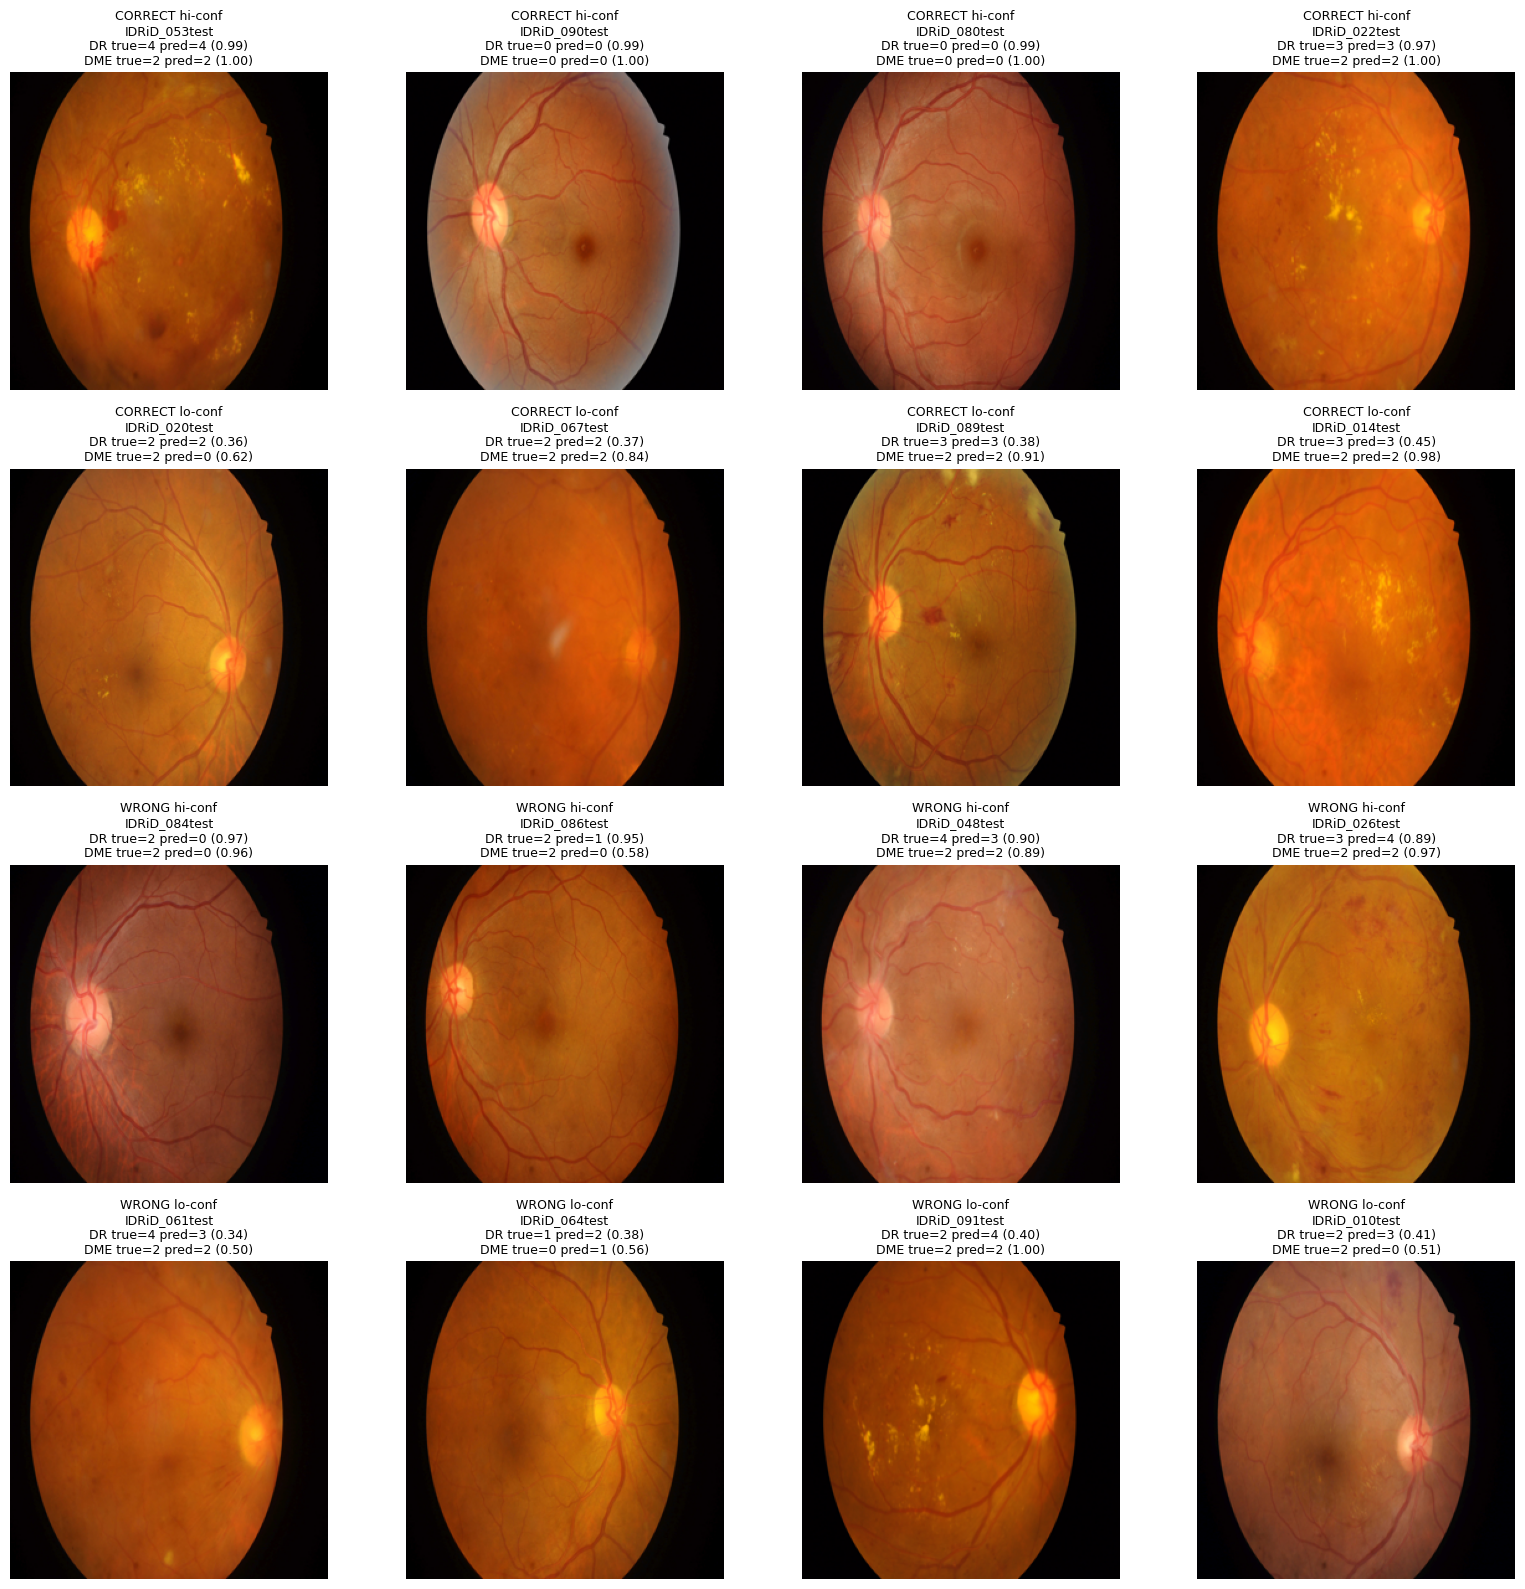

          group            id  dr_true  dr_pred  dme_true  dme_pred
CORRECT hi-conf IDRiD_053test        4        4         2         2
CORRECT hi-conf IDRiD_090test        0        0         0         0
CORRECT hi-conf IDRiD_080test        0        0         0         0
CORRECT hi-conf IDRiD_022test        3        3         2         2
CORRECT lo-conf IDRiD_020test        2        2         2         0
CORRECT lo-conf IDRiD_067test        2        2         2         2
CORRECT lo-conf IDRiD_089test        3        3         2         2
CORRECT lo-conf IDRiD_014test        3        3         2         2
  WRONG hi-conf IDRiD_084test        2        0         2         0
  WRONG hi-conf IDRiD_086test        2        1         2         0
  WRONG hi-conf IDRiD_048test        4        3         2         2
  WRONG hi-conf IDRiD_026test        3        4         2         2
  WRONG lo-conf IDRiD_061test        4        3         2         2
  WRONG lo-conf IDRiD_064test        1        2 

In [38]:
import json, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image

res = json.load(open("/kaggle/working/test_results_D_run1.json"))
exp_dr  = [[9,6,0,0,0],[2,2,1,0,0],[3,5,14,5,4],[1,1,3,14,1],[1,0,2,2,4]]
exp_dme = [[18,4,2],[1,5,2],[7,7,34]]
assert res["dr"]["confusion_matrix"] == exp_dr and res["dme"]["confusion_matrix"] == exp_dme, "wrong file"
P = res["per_image"]
errs = [p for p in P if p["dr_true"] != p["dr_pred"]]
print("DR errors:", len(errs), "| adjacent-grade:", sum(abs(p["dr_true"] - p["dr_pred"]) == 1 for p in errs))

for p in P:
    p["dr_conf"], p["dme_conf"] = max(p["dr_prob"]), max(p["dme_prob"])
    p["dr_ok"] = p["dr_true"] == p["dr_pred"]

def pick(items, reverse, n=4, max_per_grade=2):
    out, cnt = [], {}
    for p in sorted(items, key=lambda p: p["dr_conf"], reverse=reverse):
        if cnt.get(p["dr_true"], 0) >= max_per_grade: continue
        out.append(p); cnt[p["dr_true"]] = cnt.get(p["dr_true"], 0) + 1
        if len(out) == n: break
    return out

ok, bad = [p for p in P if p["dr_ok"]], [p for p in P if not p["dr_ok"]]
groups = [("CORRECT hi-conf", pick(ok, True)),  ("CORRECT lo-conf", pick(ok, False)),
          ("WRONG hi-conf",   pick(bad, True)), ("WRONG lo-conf",   pick(bad, False))]

fig, axs = plt.subplots(4, 4, figsize=(16, 16))
rows = []
for r, (name, items) in enumerate(groups):
    for c, p in enumerate(items):
        img = Image.open(os.path.join(IMG_DIR, p["id"] + ".jpg")).convert("RGB").resize((256, 256))
        axs[r, c].imshow(img); axs[r, c].axis("off")
        axs[r, c].set_title(f"{name}\n{p['id']}\nDR true={p['dr_true']} pred={p['dr_pred']} ({p['dr_conf']:.2f})\n"
                            f"DME true={p['dme_true']} pred={p['dme_pred']} ({p['dme_conf']:.2f})", fontsize=9)
        rows.append({"group": name, "id": p["id"], "dr_true": p["dr_true"], "dr_pred": p["dr_pred"],
                     "dr_probs": [round(x, 3) for x in p["dr_prob"]],
                     "dme_true": p["dme_true"], "dme_pred": p["dme_pred"],
                     "dme_probs": [round(x, 3) for x in p["dme_prob"]]})
plt.tight_layout()
plt.savefig("/kaggle/working/qualitative_D_run1.png", dpi=110); plt.show()
pd.DataFrame(rows).to_csv("/kaggle/working/qualitative_D_run1.csv", index=False)
print(pd.DataFrame(rows)[["group", "id", "dr_true", "dr_pred", "dme_true", "dme_pred"]].to_string(index=False))

## **Step 4: error analysis**

The lesion descriptions are my non-expert visual impressions from 256×256 images, so treat the causes as hypotheses to check, not findings.

## Error analysis (Model D, run 1, official test set n=80)

**Overall.** DR: 37 errors, 25 adjacent-grade (68%) and 12 two or more grades off.
Mean confidence is 0.71 on correct and 0.61 on wrong DR predictions, so confidence
is only weakly informative; 6 of 37 wrong predictions have confidence >= 0.80.
All per-class results for grade 1 (5 test images) are anecdotal.

**Failure 1 - confident under-calling of moderate disease (IDRiD_084test, _086test, _076test).**
True grade 2, predicted 0/1/0 with confidence 0.97/0.95/0.85. IDRiD_084test is also a
confident DME miss (true high-risk, predicted no-risk, p=0.96). In the panel these
images look pale/low-contrast with no obvious lesions at 256x256.
Likely cause: small lesions (microaneurysms, small haemorrhages) are lost when
4288x2848 images are squashed to 256x256. Next experiment: higher input resolution
(384 or 512) with everything else fixed; optionally contrast enhancement (CLAHE).

**Failure 2 - over-grading exudate-rich images (IDRiD_091test, IDRiD_026test).**
IDRiD_091test: true 2, predicted 4 (p=0.40); IDRiD_026test: true 3, predicted 4 (p=0.89).
Four grade-2 images are predicted as grade 4 (C1: 8, C2: 11, D: 4, so the pattern
recurs across models but shrinks). Hypothesis: bright, extensive exudates act as a
shortcut for "severe", while the DR grade depends on other lesion types.
Next step: Grad-CAM on these images to see what drives the prediction; if it is
exudates, add a lesion-aware or higher-resolution experiment.

**Failure 3 - grade 1 over-predicted; rare-class weighting side effect.**
14 images are predicted grade 1 but only 2 are correct (precision 0.14), including
6 true grade-0 images (e.g. IDRiD_068test p=0.75, IDRiD_037test p=0.68). Grade 1 has
14 training images and the largest class weight (4.54), which pushes predictions
toward it. Next experiment: softer weights (square-root inverse frequency) or
no weights, keeping the augmentation.

**Also:** 14 of 48 high-risk DME images are missed (7 as no-risk), the clinically
worst error type; 25 of 37 DR errors are adjacent-grade, consistent with an
ordinal label boundary problem (an ordinal loss is a possible follow-up).

**Reproducibility.** I retrained A, B, C1 and D once more with the same code and
seed (42). Test avg macro-F1 changed by -0.007 (A), +0.011 (B), 0.000 (C1) and
+0.083 (D: 0.568 -> 0.651). The frozen-backbone run (C1) reproduced exactly; the
runs that update convolution weights did not, plausibly because of non-deterministic
GPU kernels (not tested). So differences below about 0.1 between single runs on
80 test images are not conclusive. What is robust: pretrained ResNet-18 clearly
beats the from-scratch CNN (about 0.5+ vs 0.26), and D scored above C1 in both
runs. C2 was run once. Reported numbers are run 1; run 2 is a replicate.

In [39]:
import json
run1 = {"A": 0.2640, "B": 0.2643, "C1": 0.5140, "D": 0.5680}
ab = json.load(open("/kaggle/working/test_results_AB.json"))
cur = {"A": ab["A"], "B": ab["B"],
       "C1": json.load(open("/kaggle/working/test_results_C1.json")),
       "D":  json.load(open("/kaggle/working/test_results_D_run2.json"))}
print(f"{'Run':4s} {'run1':>8s} {'run2':>8s} {'diff':>8s}")
for k, r in cur.items():
    v = (r["dr"]["macro_f1"] + r["dme"]["macro_f1"]) / 2
    print(f"{k:4s} {run1[k]:8.4f} {v:8.4f} {v-run1[k]:+8.4f}")

Run      run1     run2     diff
A      0.2640   0.2568  -0.0072
B      0.2643   0.2751  +0.0108
C1     0.5140   0.5140  +0.0000
D      0.5680   0.6505  +0.0825


## Label formulation

Each image has two targets: DR grade (5 classes, 0-4) and DME risk (3 classes, 0-2).
Within one task the classes are mutually exclusive, since an image has exactly one
grade and one risk level. So the model is **multi-task classification with two
independent softmax heads** on a shared encoder, each trained with cross-entropy
(`loss = L_dr + L_dme`, equal weights of 1; both are cross-entropy on similar
scales, so no tuning was done).

I did **not** use one 8-unit sigmoid output. That would treat the 8 outputs as
independent yes/no labels, so it could predict two DR grades at once or no grade
at all, and it ignores that the classes within a task compete. Decoding is
`argmax` within each head, so every image always gets exactly one grade and one
risk level. Grades are ordered, and an ordinal loss would be a natural extension;
it was not tried here.